# Figure 2 — Acquisition Results

Reconstructs Figure 2 (acquisition results) from the 2S2C manuscript using the rebuilt parquet pipeline.

**Cohort:** 41 rats (PI+VC: 17, PI: 12, VC: 12) — see [config/subjects.yaml](../config/subjects.yaml); acquisition criterion ≥ 24/32 correct on the final acquisition session (binomial p ≤ 0.01).

**Panels:**
- **2A** — schematic (assembled externally)
- **2B** — trials to criterion, by group (bar + scatter)
- **2C** — % correct per session, aligned to criterion (line plot)
- **2D** — accuracy across 4 trial blocks on final acquisition session (line plot)
- **2E** — 1st vs 2nd choice accuracy over last 5 training sessions (scatter + lines)
- **2F** — trained 2nd response on goal-side vs non-goal-side (bar + scatter)
- **2G** — PI+VC (fixed 1st) vs PI+VC (fixed 2nd): trials to criterion, learning curves, block accuracy, and the 1st-vs-2nd choice-point difference score

**Panel G cohort:** the 6-rat PI+VC (fixed 1st, "F1") cohort from `subjects.yaml` (`figure2.PI+VC_f1`) vs the 17 PI+VC rats above (fixed 2nd). Loaded separately in the Panel G section (every Panel G object is suffixed `_g`).

## Preamble — load data, cohort, style

### Imports & paths
Standard imports plus project-relative paths. `PROJECT_ROOT` is one level up from `notebooks/`, so data, config, and figure-output folders are resolved once and reused below.

In [1]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]   # figures/notebooks/ -> repo root
DATA = PROJECT_ROOT / 'data' / 'processed'
CONFIG = PROJECT_ROOT / 'config'
FIG_OUT = PROJECT_ROOT / 'figures' / 'images'
FIG_OUT.mkdir(exist_ok=True)

pd.set_option('display.max_columns', None, 'display.width', 200)

### Load cohort and parquets
Read the manuscript subject list from [config/subjects.yaml](../config/subjects.yaml), load `subjects`, `sessions`, and `trials` parquets, then filter to the 41 Fig 2 rats and attach the group label. The printed table shows **PI+VC 17 (8M/9F), PI 12 (6M/6F), VC 12 (7M/5F)**.

In [2]:
# Paper cohort. `figure2` in subjects.yaml lists all 47 rats in the paper; Panels B-F use
# the 41 main-cohort rats (PI+VC, PI, VC) and the 6 F1 rats (PI+VC_f1) enter only in Panel G.
cohort = yaml.safe_load((CONFIG / 'subjects.yaml').read_text())['figure2']
MAIN_GROUPS = ['PI+VC', 'PI', 'VC']
subj_to_group = {sid: g for g in MAIN_GROUPS for sid in cohort[g]}
cohort_ids = list(subj_to_group)

# Parquets
subjects = pd.read_parquet(DATA / 'subjects.parquet')
sessions = pd.read_parquet(DATA / 'sessions.parquet')
trials   = pd.read_parquet(DATA / 'trials.parquet')

# Filter to cohort and attach group
subjects = subjects[subjects['subject_id'].isin(cohort_ids)].copy()
subjects['group'] = subjects['subject_id'].map(subj_to_group)
sessions = sessions[sessions['subject_id'].isin(cohort_ids)].copy()
sessions['group'] = sessions['subject_id'].map(subj_to_group)
trials = trials.merge(sessions[['session_id','subject_id','group','session_experiment_phase']], on='session_id', how='inner')

print(f'Cohort: {len(subjects)} rats')
print(subjects.groupby(['group','sex'], observed=True).size().unstack(fill_value=0))

Cohort: 41 rats
sex    F  M
group      
PI     6  6
PI+VC  9  8
VC     5  7


### Style configuration
Per-group colors, hatches, line styles, and markers follow the Wong/Nature colorblind-safe palette defined in [docs/journal_figure_specs.md](../docs/journal_figure_specs.md). `rcParams` enforce *Learning & Memory* specs (Helvetica 8–10 pt labels, line widths ≥ 0.25 pt, PDF font type 42 for editable text). `figure.dpi = 200` zooms the notebook preview without affecting the saved PDF, which remains vector and sized to `figsize` in inches.

In [3]:
# Group style (from docs/journal_figure_specs.md — Wong/Nature palette)
# `hatch_color` is the fill->base midpoint: lighter than the dark edge,
# distinct from the bar fill, for a readable hatch overlay.
# PI+VC = green (blue+yellow make green), PI = blue, VC = yellow
# Tint/shade factors: fill = base + 55% toward white; edge = 62% of base.
GROUP_ORDER = ['PI+VC', 'PI', 'VC']
STYLE = {
    'PI+VC': {'fill': '#8FD4BE', 'base': '#009E73', 'edge': '#00624A', 'hatch_color': '#47B998', 'hatch': '',     'line': '-',  'marker': 'o'},
    'PI':    {'fill': '#AADCF4', 'base': '#56B4E9', 'edge': '#2B6F94', 'hatch_color': '#80C8EE', 'hatch': '///',  'line': '--', 'marker': 's'},
    'VC':    {'fill': '#F4CF80', 'base': '#E69F00', 'edge': '#8A5F00', 'hatch_color': '#EDB740', 'hatch': '...', 'line': '-.', 'marker': '^'},
    # Panel G only: the PI+VC (fixed 1st) cohort. Wong reddish-purple — chosen so F1
    # reads as a member of the PI+VC family; under deuteranopia its tint sits close to
    # PI+VC's, and the backslash hatch / dotted line / diamond marker carry the distinction.
    # (Vermillion #D55E00 was the alternative with the largest CVD separation.)
    'PI+VC_f1': {'fill': '#E8C3D7', 'base': '#CC79A7', 'edge': '#7E4B68', 'hatch_color': '#DA9EBF', 'hatch': '\\\\\\', 'line': ':', 'marker': 'D'},
}
# Panel G group order / tick labels (fixed 1st vs fixed 2nd). GROUP_ORDER drives A–F.
GROUP_ORDER_G = ['PI+VC_f1', 'PI+VC']
GROUP_LABELS_G = {'PI+VC_f1': 'F1', 'PI+VC': 'PI+VC'}


# Per-panel small-element style knobs (not handled by rcParams).
# Edit values here to propagate to all panels via their function defaults.
# All values fall within Cell's 0.5-1.5 pt line-width range; annotation fonts
# (star/ns at 6 pt) sit just below the body 6-8 pt range for compactness.
STYLE_CFG = {
    # Bar / patch edge strokes
    'bar_edge_lw':         0.5,   # bar fill outline (panels B, F, G2)
    'legend_frame_lw':     0.5,   # FancyBboxPatch / legend Patch borders (B, F, G2)
    'legend_content_color': '0.3', # legend text + neutral-symbol color (all panels). Matplotlib gray; '0.3' = 3 steps down from black on a 1=white→10=black scale
    # Scatter edge strokes (vary by panel — keep separate)
    'scatter_edge_lw_b':   0.6,   # panel B main scatter + in-legend markers (also G2)
    'scatter_edge_lw_f':   0.5,   # panel F goal/non-goal scatter
    'scatter_edge_lw_g':   0.5,   # panel G5 per-rat diff-score scatter
    # Line-plot marker edge strokes
    'marker_edge_lw_d':    0.6,   # panel D errorbar markers + legend (also G4, G5)
    'marker_edge_lw_e':    0.5,   # panel E choice markers + legend
    # Marker sizes (global defaults across panels)
    'scatter_s':          10,     # scatter-style marker area (pt²) — ax.scatter(s=...)
    'marker_size':         3.2, #3.16,  # line-style marker diameter (pt)  — Line2D markersize=...
                                  # 3.16 = sqrt(10) so a line marker visually matches scatter_s=10
    # Connectors / errorbars / reference lines
    'pair_line_lw':        0.6,   # panel E within-rat paired connectors
    'err_lw':              0.9,   # panel D errorbar line + cap thickness (also G4, G5)
    'cap_size':            2,     # panel D errorbar cap size (also G4, G5)
    'axhline_lw':          0.8,   # panel F chance-line reference
    'axhline_lw_g':        0.6,   # panel G5 zero-line reference
    # Annotation fonts
    'star_fontsize':       6,     # significance asterisks (D, E, F, G5)
    'ns_fontsize':         6,     # 'ns' annotation (E, G5)
}

# --- Helvetica bold / oblique faces ------------------------------------------
# macOS ships Helvetica as a .ttc collection and matplotlib's font manager indexes
# only its first face (Regular, weight 400), so fontweight='bold' silently fell back
# to regular in every panel (the PDF embedded no Helvetica-Bold). Split the
# collection into standalone .ttf faces once (user-local, outside the repo) and
# register them so 'bold' resolves to Helvetica-Bold.ttf.
from matplotlib import font_manager as _fm
_HELV_TTC = Path('/System/Library/Fonts/Helvetica.ttc')
_HELV_DIR = Path.home() / '.matplotlib' / 'helvetica_faces'
if _HELV_TTC.exists():
    if not any(_HELV_DIR.glob('*.ttf')):
        from fontTools.ttLib import TTCollection
        _HELV_DIR.mkdir(parents=True, exist_ok=True)
        for _face in TTCollection(str(_HELV_TTC)).fonts:
            _face.save(str(_HELV_DIR / f"{_face['name'].getDebugName(6)}.ttf"))
    for _p in _HELV_DIR.glob('*.ttf'):
        _fm.fontManager.addfont(str(_p))
_bold_face = Path(_fm.findfont(_fm.FontProperties(family='Helvetica', weight='bold'))).name
if 'Bold' not in _bold_face:
    print(f'WARNING: Helvetica bold resolved to {_bold_face}; panel letters/stars will render regular')
else:
    print(f'Helvetica bold face: {_bold_face}')

# Typography: Cell Press floor (https://www.cell.com/figureguidelines). Target journal Hippocampus (Wiley) sets NO numeric font minimum, only "legible at 80 mm width unmagnified" - see docs/journal_figure_specs.md:
#   Font: Helvetica/Arial, sans-serif, consistent across figures
#   Body text (axis labels, ticks, legend, in-panel): 6-8 pt at final print size
#   Panel labels (A, B, C...): 8 pt bold, upright, uppercase, upper-left of panel
#   Line width: 0.5-1.5 pt at final print size (avoid hairlines <0.25 pt)
#   Widths (final, Wiley): 80 mm single-column / 180 mm full page; Wiley states no max height (Cell 225 mm as sanity cap)
#   Resolution at final size: halftone >=300 dpi, B&W halftone >=500, line art >=1000
#   Format: vector PDF preferred (editable text, fonts embedded/outlined)
plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 8,
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'xtick.minor.width': 0.75,
    'ytick.minor.width': 0.75,
    'lines.linewidth': 0.75,
    'patch.linewidth': 0.75,
    'hatch.linewidth': 0.75,
    'pdf.fonttype': 42,   # embed TrueType, keep text editable in vector PDF
    'ps.fonttype': 42,
    # Display zoom -- notebook preview only, doesn't affect saved PDF size
    'figure.dpi': 200,     # inline render DPI; bump higher to zoom preview
    'savefig.dpi': 300,    # raster export DPI (ignored for vector PDF/SVG)
})


Helvetica bold face: Helvetica-Bold.ttf


## Panel 2B — Trials to criterion

Bar = group mean; scatter = individual rats (sex: filled = male, open = female; approach: D = toward, s = away, o = none).

### Panel 2B data — trials to criterion per rat
Sum `total_trials` across all acquisition sessions for each rat, then group by training group. Expected means (from the manuscript): **PI+VC 156.3 ± 10.2, PI 146.0 ± 8.9, VC 183.2 ± 13.2**. Rebuilt pipeline values differ only on PI+VC by a few trials (159.4 vs 156.3) — traceable to small differences in session-merge handling; PI and VC match essentially exactly.

In [4]:
# Trials to criterion = sum of total_trials over acquisition sessions
acq = sessions[sessions['session_experiment_phase'] == 'Acquisition']
tta = (
    acq.groupby(['group','subject_id'], observed=True)['total_trials']
    .sum()
    .reset_index(name='trials_to_criterion')
    .merge(subjects[['subject_id','sex','approach_to_goal']], on='subject_id')
)
tta.groupby('group', observed=True)['trials_to_criterion'].agg(['mean','sem','count'])

,mean,sem,count
group,,,
PI,146.583333,8.671145,12
PI+VC,159.411765,10.258088,17
VC,186.166667,13.963607,12


### Panel 2B figure
Bars = group mean; scatter = individual rats. Marker shape encodes approach direction (◆ toward / ■ away / ● none), marker fill encodes sex (filled = M, open = F), edge color = group shade. The inset M/F × cue table in the upper-left serves as the figure key.

**Knobs** for layout are grouped at the top of the cell — figure size, axes size, legend placement, content spacing, box size, content offsets, and shade. Adjust those and re-run; the rest of the cell is pure rendering.

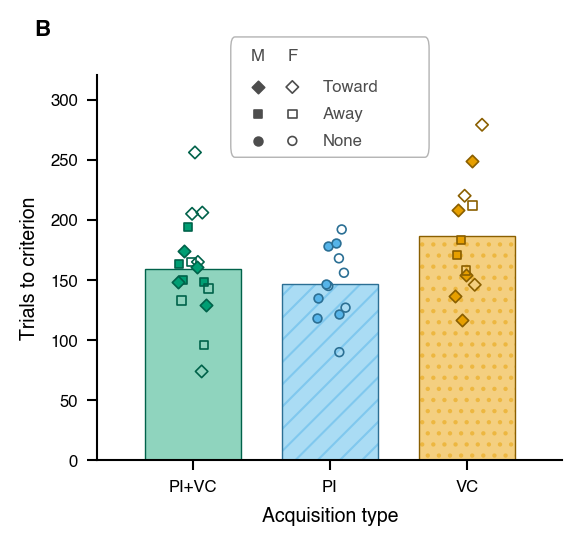

In [5]:
# Panel 2B — bar + scatter (function form)
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import blended_transform_factory
from matplotlib.lines import Line2D

def panel_b(ax, scatter_s=STYLE_CFG['scatter_s'], bar_width=0.7, scatter_jitter=0.12,
            ylim=(0, 320), yticks=None, ylabel='Trials to criterion',
            xlabel='Acquisition type', xlim=(-0.7, 2.7), xticklabels=None,
            bar_edge_lw=STYLE_CFG['bar_edge_lw'],
            scatter_edge_lw=STYLE_CFG['scatter_edge_lw_b'],
            legend_frame_lw=STYLE_CFG['legend_frame_lw'],
            show_legend=True, legend_center_x=1.0, legend_top_y=1.1,
            legend_box_w=1.45, legend_box_dx=0, legend_box_dy=0, legend_box_h=0.3125, legend_content_dx=-0.25,
            legend_fontsize=6, legend_marker_s=STYLE_CFG['scatter_s'],
            # Data source: None -> Panel B globals (tta / GROUP_ORDER).
            # Panel G2 passes its own frame + groups so it draws with identical code.
            # uniform_marker: None -> marker encodes cue approach (D toward / s away / o none);
            # a marker string (e.g. 'o') uses that shape for every rat (G2: approach is
            # not meaningful for the fixed-1st cohort). Sex stays filled (M) / open (F).
            data=None, groups=None, uniform_marker=None):
    """Panel 2B: trials to criterion bar + scatter."""
    MARKER_BY_APPROACH = {'toward': 'D', 'away': 's', 'none': 'o'}
    rng = np.random.default_rng(42)
    tta_ = tta if data is None else data
    groups = GROUP_ORDER if groups is None else list(groups)
    x_pos = {g: i for i, g in enumerate(groups)}

    # Bars
    for g in groups:
        st = STYLE[g]
        mean = tta_.loc[tta_['group'] == g, 'trials_to_criterion'].mean()
        # Fill, hatch, then border on top (same layering as panel F), so the
        # hatch sits under the bar edge instead of over it.
        ax.bar(x_pos[g], mean, width=bar_width,
               facecolor=st['fill'], edgecolor='none', linewidth=0, zorder=2)
        if st['hatch']:
            ax.bar(x_pos[g], mean, width=bar_width,
                   facecolor='none', edgecolor=st['hatch_color'],
                   hatch=st['hatch'], linewidth=0, zorder=2.1)
        ax.bar(x_pos[g], mean, width=bar_width,
               facecolor='none', edgecolor=st['edge'], linewidth=bar_edge_lw, zorder=2.2)

    # Scatter
    for _, r in tta_.iterrows():
        if r['group'] not in x_pos:
            continue
        st = STYLE[r['group']]
        marker = uniform_marker or MARKER_BY_APPROACH.get(str(r['approach_to_goal']).lower(), 'o')
        is_female = str(r['sex']).upper().startswith('F')
        face = 'none' if is_female else st['base']
        ax.scatter(x_pos[r['group']] + rng.uniform(-scatter_jitter, scatter_jitter),
                   r['trials_to_criterion'], marker=marker, s=scatter_s,
                   facecolor=face, edgecolor=st['edge'], linewidth=scatter_edge_lw, zorder=3, clip_on=False)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(groups if xticklabels is None else xticklabels)
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        trans = blended_transform_factory(ax.transData, ax.transAxes)
        APPROACHES = [('toward', 'D'), ('away', 's'), ('none', 'o')]
        col_w, label_gap, row_h, header_gap = 0.25, 0.10, 0.07, 0.1
        box_radius = 0.03
        content_color, box_color = STYLE_CFG['legend_content_color'], '0.7'
        content_w = col_w * 2 + label_gap + 0.20
        box_left = legend_center_x - legend_box_w / 2 + legend_box_dx
        content_x0 = legend_center_x - content_w / 2 + legend_content_dx
        ax.add_patch(FancyBboxPatch(
            (box_left, legend_top_y - legend_box_h + legend_box_dy), legend_box_w, legend_box_h,
            boxstyle=f'round,pad=0,rounding_size={box_radius}',
            linewidth=legend_frame_lw, edgecolor=box_color, facecolor='white',
            transform=trans, zorder=10, clip_on=False))
        hy = legend_top_y - 0.03
        ax.text(content_x0 + col_w*0.5, hy, 'M', ha='center', va='top', fontsize=legend_fontsize,
                color=content_color, transform=trans, zorder=11)
        ax.text(content_x0 + col_w*1.5, hy, 'F', ha='center', va='top', fontsize=legend_fontsize,
                color=content_color, transform=trans, zorder=11)
        for i, (label, marker) in enumerate(APPROACHES):
            y = hy - header_gap - i * row_h
            ax.scatter(content_x0 + col_w*0.5, y, marker=marker, s=legend_marker_s,
                       facecolor=content_color, edgecolor=content_color, linewidth=scatter_edge_lw,
                       transform=trans, zorder=11, clip_on=False)
            ax.scatter(content_x0 + col_w*1.5, y, marker=marker, s=legend_marker_s,
                       facecolor='none', edgecolor=content_color, linewidth=scatter_edge_lw,
                       transform=trans, zorder=11, clip_on=False)
            ax.text(content_x0 + col_w*2 + label_gap, y, label.capitalize(),
                    ha='left', va='center', fontsize=legend_fontsize,
                    color=content_color, transform=trans, zorder=11)

# Standalone preview
_fig, _ax = plt.subplots(figsize=(3.0, 2.5))
panel_b(_ax)
_fig.text(0.02, 0.96, 'B', fontsize=8, fontweight='bold')
plt.show()


### ANOVA assumption checks
Before running the one-way ANOVA on trials to criterion, verify two assumptions:
- **Shapiro–Wilk** per group: want p > .05 (residuals are approximately normal).
- **Levene's test**: want p > .05 (variances are homogeneous across groups).

A QQ-plot of pooled within-group residuals provides a visual normality check. Points should lie on the diagonal; minor deviations at the tails are expected with n≈41. All three groups passed both tests, so the parametric ANOVA is appropriate for this panel.

Shapiro-Wilk normality (per group):
  PI+VC   W = 0.965, p = 0.717
  PI      W = 0.976, p = 0.965
  VC      W = 0.964, p = 0.835

Levene (equal variance): W = 1.070, p = 0.353


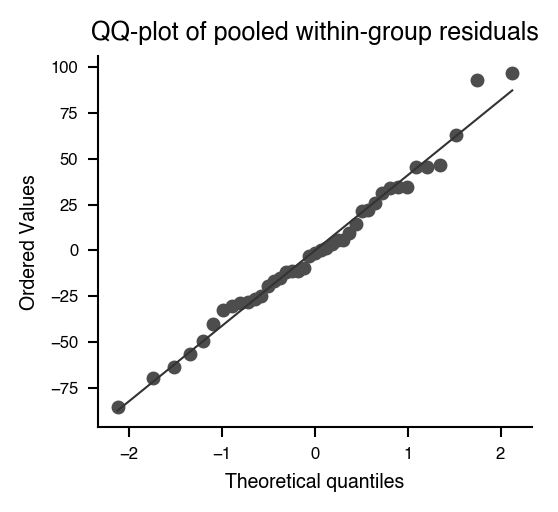

In [6]:
# Panel 2B ANOVA assumption checks
from scipy import stats

groups = {g: tta.loc[tta['group'] == g, 'trials_to_criterion'].values for g in GROUP_ORDER}

# 1) Normality — Shapiro-Wilk per group
#    H0: data are drawn from a normal distribution. p > .05 → fail to reject (OK).
print('Shapiro-Wilk normality (per group):')
for g, vals in groups.items():
    W, p = stats.shapiro(vals)
    flag = '' if p > .05 else '  ← non-normal'
    print(f'  {g:6s}  W = {W:.3f}, p = {p:.3f}{flag}')

# 2) Homogeneity of variance — Levene's test (robust to non-normality)
#    H0: all groups have equal variance. p > .05 → OK for ANOVA.
L, p_levene = stats.levene(*groups.values(), center='median')
print(f'\nLevene (equal variance): W = {L:.3f}, p = {p_levene:.3f}'
      f'{"" if p_levene > .05 else "  ← variances differ"}')

# 3) QQ-plot of residuals across groups (visual normality check)
grand_resid = np.concatenate([vals - vals.mean() for vals in groups.values()])
fig_qq, ax_qq = plt.subplots(figsize=(2.8, 2.6))
stats.probplot(grand_resid, dist='norm', plot=ax_qq)
ax_qq.set_title('QQ-plot of pooled within-group residuals', fontsize=9)
ax_qq.get_lines()[0].set_markerfacecolor('0.3')
ax_qq.get_lines()[0].set_markeredgecolor('0.3')
ax_qq.get_lines()[0].set_markersize(4)
ax_qq.get_lines()[1].set_color('0.2')
ax_qq.spines['top'].set_visible(False)
ax_qq.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Interpretation: if Shapiro or Levene flags violations, prefer the
# non-parametric Kruskal-Wallis (below) over the one-way ANOVA.

### Replicate manuscript statistics
- **One-way ANOVA on trials to criterion**: manuscript reports F(2, 41) = 2.79, p = .074. That df is a typo — a 3-group ANOVA has df = (2, N-3), so F(2, 41) would require N = 44; the 41-rat cohort gives (2, 38). Rebuilt value F(2, 38) = 2.92, p = .066 reproduces the paper’s trend, with the small drift traceable to the PI+VC mean difference above.
- **Kruskal–Wallis on sessions to criterion**: manuscript reports H(2) = 4.24, p = .12; we get H(2) = 4.83, p = .089 — same conclusion (no significant group effect on session count).

Both tests agree: a non-significant trend toward more trials for VC, no significant effect on sessions.

In [7]:
# Panel 2B stats — replicate manuscript tests
from scipy import stats

groups = {g: tta.loc[tta['group'] == g, 'trials_to_criterion'].values for g in GROUP_ORDER}

# One-way ANOVA on trials to criterion (manuscript: F2,41=2.79, p=.074)
F, p_anova = stats.f_oneway(*groups.values())
n_total = sum(len(v) for v in groups.values())
df_between = len(groups) - 1
df_within = n_total - len(groups)
print(f'One-way ANOVA (trials to criterion): F({df_between},{df_within}) = {F:.2f}, p = {p_anova:.3f}')

# Kruskal–Wallis on sessions to criterion (manuscript: H2=4.24, p=.12)
sess_to_crit = (
    sessions[sessions['session_experiment_phase'] == 'Acquisition']
    .groupby(['group','subject_id'], observed=True)
    .size()
    .reset_index(name='sessions_to_criterion')
)
sess_groups = [sess_to_crit.loc[sess_to_crit['group'] == g, 'sessions_to_criterion'].values for g in GROUP_ORDER]
H, p_kw = stats.kruskal(*sess_groups)
print(f'Kruskal–Wallis (sessions to criterion): H({len(GROUP_ORDER)-1}) = {H:.2f}, p = {p_kw:.3f}')

# Sessions to criterion by group (manuscript quotes the medians: PI+VC 7, PI 5, VC 7)
sess_summary = (sess_to_crit.groupby('group', observed=True)['sessions_to_criterion']
                .agg(['median', 'mean', 'min', 'max', 'count']).loc[GROUP_ORDER])
print('\nSessions to criterion by group:')
print(sess_summary.round(2).to_string())

One-way ANOVA (trials to criterion): F(2,38) = 2.92, p = 0.066
Kruskal–Wallis (sessions to criterion): H(2) = 4.83, p = 0.089

Sessions to criterion by group:
       median  mean  min  max  count
group                               
PI+VC     7.0  6.94    3   11     17
PI        5.0  5.75    3   12     12
VC        7.0  6.75    5    9     12


### Post-hoc: Tukey HSD (exploratory — not in manuscript)
The omnibus ANOVA is only borderline (p = .066), but it's useful to see which pairwise contrast is driving the trend. **VC vs PI** is the strongest pairwise difference (+39.6 trials, p = .060) — consistent with the manuscript's narrative that "VC rats required more trials to reach criterion than the other two groups." Not statistically significant after correction, so we report it as a trend.

In [8]:
# Pairwise post-hoc — Tukey HSD on trials to criterion
tukey = stats.tukey_hsd(*groups.values())
print('Tukey HSD (trials to criterion):')
for i, g1 in enumerate(GROUP_ORDER):
    for j, g2 in enumerate(GROUP_ORDER):
        if i < j:
            print(f'  {g1:6s} vs {g2:6s}: mean diff = {tukey.statistic[i,j]:+6.1f}, p = {tukey.pvalue[i,j]:.3f}')

Tukey HSD (trials to criterion):
  PI+VC  vs PI    : mean diff =  +12.8, p = 0.689
  PI+VC  vs VC    : mean diff =  -26.8, p = 0.209
  PI     vs VC    : mean diff =  -39.6, p = 0.060


### Exploratory: group × sex ANOVA
The manuscript did not analyze sex as a factor. Running a 2-way ANOVA (group × sex) for transparency — cell sizes are 6–9 per cell, balanced enough to interpret. `approach_to_goal` is dropped from the model because PI rats by design have no "toward" cue condition, which makes the full interaction unestimable.

Results show **no main effect of sex** (F = 0.26, p = .62) and **no group × sex interaction** (F = 0.22, p = .80). The group effect remains a trend (F = 2.47, p = .099). Takeaway: the group-level pattern reported in the paper holds when sex is included in the model.

In [9]:
# 2-way ANOVA: group × sex (exploratory — not in manuscript)
# Approach dropped: PI group has no 'toward' rats by design (no visual cue).
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

df2 = tta.copy()
df2['sex'] = df2['sex'].str.upper().str[0]   # M / F
df2 = df2.rename(columns={'group': 'grp'})    # patsy reserves 'group'

print('Cell sizes (group × sex):')
print(df2.groupby(['grp','sex'], observed=True).size().unstack(fill_value=0))
print()

model = smf.ols('trials_to_criterion ~ C(grp) * C(sex)', data=df2).fit()
aov = anova_lm(model, typ=2)
print('Type II ANOVA (trials to criterion ~ group × sex):')
print(aov.round(3))

Cell sizes (group × sex):
sex    F  M
grp        
PI     6  6
PI+VC  9  8
VC     5  7

Type II ANOVA (trials to criterion ~ group × sex):
                  sum_sq    df      F  PR(>F)
C(grp)         10270.167   2.0  2.906   0.068
C(sex)           815.002   1.0  0.461   0.501
C(grp):C(sex)   1630.801   2.0  0.462   0.634
Residual       61838.899  35.0    NaN     NaN


## Panel 2C — % correct per session, aligned to criterion

Line plot showing learning trajectory. X-axis = sessions to criterion (final acquisition session = 0, counting backward). Lines show group median per session index; scatter shows individual rats. Matches the manuscript definition of a correct trial: rat entered the rewarded corner first before visiting any unrewarded corner (i.e. `errors == 0`).

### Panel 2C data — per-rat, per-session-index accuracy

For each rat:
1. Number their acquisition sessions backward from the final one (0 = criterion session, 1 = prior, ...).
2. Compute % correct trials per session.

Then take the median per group at each session-to-criterion index. Rats with fewer sessions simply contribute to fewer bins on the left side of the plot.

In [10]:
# Compute per-rat, per-session-index accuracy
# session_to_criterion: 0 = final (criterion) session, 1 = one before, etc.
acq_sessions = sessions[sessions['session_experiment_phase'] == 'Acquisition'].copy()
acq_sessions = acq_sessions.sort_values(['subject_id', 'session_id'])
acq_sessions['session_rank_desc'] = (
    acq_sessions.groupby('subject_id', observed=True)
    .cumcount(ascending=False)
)

# Correct trial (manuscript definition): rat reached goal before any wrong well
acq_trials = trials[trials['session_experiment_phase'] == 'Acquisition'].copy()
acq_trials['correct'] = (acq_trials['errors'] == 0).astype(float)
pct_by_session = (
    acq_trials.groupby('session_id', observed=True)['correct']
    .mean()
    .reset_index(name='pct_correct')
)

sess_acc = acq_sessions[['session_id','subject_id','group','session_rank_desc']].merge(
    pct_by_session, on='session_id'
)
print('Sessions per rat (range):',
      sess_acc.groupby('subject_id').size().agg(['min','max','median']).to_dict())
print()
print('Group median pct_correct by session-to-criterion (0=final):')
print(
    sess_acc.pivot_table(index='session_rank_desc', columns='group',
                         values='pct_correct', aggfunc='median', observed=True)
    .round(2)
    .head(15)
)

Sessions per rat (range): {'min': 3.0, 'max': 12.0, 'median': 6.0}

Group median pct_correct by session-to-criterion (0=final):
group                PI  PI+VC    VC
session_rank_desc                   
0                  0.88   0.94  0.92
1                  0.83   0.94  0.83
2                  0.62   0.88  0.58
3                  0.50   0.75  0.53
4                  0.31   0.58  0.50
5                  0.45   0.46  0.45
6                  0.36   0.38  0.44
7                  0.50   0.44  0.09
8                  0.40   0.22  0.04
9                  0.58   0.12   NaN
10                 0.00   0.08   NaN
11                 0.36    NaN   NaN


### Panel 2C figure

Line plot with median trajectory per group; individual rats shown as translucent scatter. X-axis flipped so criterion (0) is on the right, matching the manuscript. Line style is redundant with color per the figure spec (PI+VC solid / PI dashed / VC dotted) for colorblind readers.

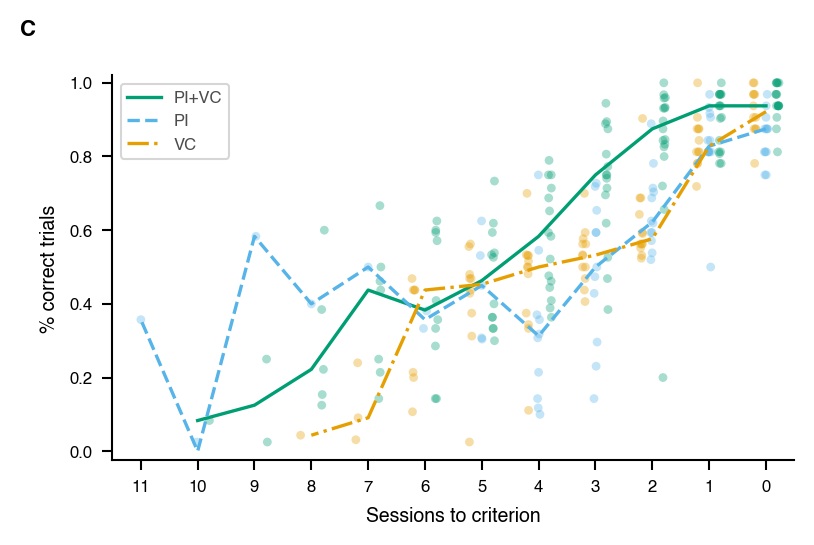

In [11]:
# Panel 2C — learning curves (function form)
from matplotlib.lines import Line2D

def panel_c(ax,
            # Line / scatter geometry
            line_lw=1.2, scatter_s=STYLE_CFG['scatter_s'], scatter_alpha=0.35,
            group_offset=0.20, within_jitter=0.03,
            # Axes
            xlim=None, xticks=None, xlabel='Sessions to criterion',
            ylim=(-0.025, 1.02), yticks=None, ylabel='% correct trials',
            # Legend
            show_legend=True, legend_loc='upper left',
            legend_fontsize=None, legend_handletextpad=0.8,
            legend_borderpad=0.4, legend_bbox_to_anchor=None,
            legend_top_y=None, legend_x=None,
            # Data source: None -> Panel C globals (sess_acc / GROUP_ORDER).
            # Panel G3 passes its own frame + groups; `labels` maps group -> legend text;
            # `min_n` (None = draw every session) hides the median line where fewer than
            # min_n rats remain at that session-to-criterion.
            data=None, groups=None, labels=None, min_n=None):
    """Panel 2C: learning curves aligned to criterion."""
    rng = np.random.default_rng(42)
    sess_ = sess_acc if data is None else data
    groups = GROUP_ORDER if groups is None else list(groups)
    labels = {} if labels is None else labels
    x_max = int(sess_['session_rank_desc'].max())
    zero_float = 0.025

    centered_offsets = {
        g: (i - (len(groups) - 1) / 2) * group_offset
        for i, g in enumerate(groups)
    }
    for g in groups:
        st = STYLE[g]
        d = sess_[sess_['group'] == g]
        offset = centered_offsets[g]
        y_scatter = d['pct_correct'].where(d['pct_correct'] != 0, zero_float)
        jitter = rng.uniform(-within_jitter, within_jitter, size=len(d)) if within_jitter > 0 else 0
        ax.scatter(d['session_rank_desc'] + offset + jitter, y_scatter,
                   s=scatter_s, facecolor=st['base'], edgecolor='none',
                   alpha=scatter_alpha, zorder=2)
        med = d.groupby('session_rank_desc', observed=True)['pct_correct'].median()
        if min_n is not None:
            n_rats = d.groupby('session_rank_desc', observed=True)['subject_id'].nunique()
            med = med[n_rats.reindex(med.index) >= min_n]
        ax.plot(med.index, med.values, color=st['base'], linestyle=st['line'],
                linewidth=line_lw, zorder=3, label=labels.get(g, g))

    if xlim is None:
        xlim = (x_max + 0.5, -0.5)
    ax.set_xlim(*xlim)
    if xticks is None:
        xticks = list(range(0, x_max + 1))
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    ax.set_xlabel(xlabel)

    ax.set_ylim(*ylim)
    if yticks is None:
        yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        handles = [Line2D([], [], color=STYLE[g]['base'], linestyle=STYLE[g]['line'],
                          linewidth=line_lw, label=labels.get(g, g)) for g in groups]
        # Shorthand knobs: legend_x and legend_top_y set the legend anchor in axes
        # fractions. legend_loc determines which corner is anchored:
        #   left/right/center half → x corner;  upper/lower/center half → y corner.
        # legend_top_y forces 'upper *' (anchors the legend's top edge).
        # An explicit legend_bbox_to_anchor wins over both.
        eff_loc, eff_bbox = legend_loc, legend_bbox_to_anchor
        if eff_bbox is None and (legend_top_y is not None or legend_x is not None):
            ll = legend_loc.lower()
            if 'right' in ll:
                ax_default, h = 1.0, 'right'
            elif 'left' in ll:
                ax_default, h = 0.0, 'left'
            else:
                ax_default, h = 0.5, 'center'
            if legend_top_y is not None:
                v, ay_default = 'upper', legend_top_y
            elif 'upper' in ll:
                v, ay_default = 'upper', 1.0
            elif 'lower' in ll:
                v, ay_default = 'lower', 0.0
            else:
                v, ay_default = 'center', 0.5
            bx = legend_x if legend_x is not None else ax_default
            eff_loc = f'{v} {h}' if not (v == 'center' and h == 'center') else 'center'
            eff_bbox = (bx, ay_default)
        leg_kwargs = dict(loc=eff_loc, frameon=True,
                          handletextpad=legend_handletextpad,
                          borderpad=legend_borderpad)
        if legend_fontsize is not None:
            leg_kwargs['fontsize'] = legend_fontsize
        if eff_bbox is not None:
            leg_kwargs['bbox_to_anchor'] = eff_bbox
        leg = ax.legend(handles=handles, **leg_kwargs)
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

# Standalone preview
_fig, _ax = plt.subplots(figsize=(4.4, 2.5))
panel_c(_ax)
_fig.text(0.02, 0.96, 'C', fontsize=8, fontweight='bold')
plt.show()


### Exploratory: per-rat logistic learning slope (not in manuscript)

Each acquisition trial is a Bernoulli outcome (`correct = errors == 0`). Fit a per-rat logistic regression

$$\mathrm{logit}(P_{\mathrm{correct}}) = \beta_0 + \beta_1 \cdot \mathrm{session\_from\_start}$$

using all of the rat's acquisition trials. The slope $\beta_1$ is the change in log-odds of a correct trial per additional session — a compact summary of learning rate that respects the binary nature of the data and the sigmoidal shape of the learning curve.

Then test whether slopes differ across groups with a one-way ANOVA on the per-rat slopes.

In [12]:
# Per-rat logistic regression: logit(P correct) ~ session_from_start
import statsmodels.api as sm

# Build trial-level table with "session_from_start" (0 = first acquisition session)
acq_sessions_sorted = (
    sessions[sessions['session_experiment_phase'] == 'Acquisition']
    .sort_values(['subject_id', 'session_id'])
    .copy()
)
acq_sessions_sorted['session_from_start'] = (
    acq_sessions_sorted.groupby('subject_id', observed=True).cumcount()
)
sess_idx = acq_sessions_sorted[['session_id', 'session_from_start']]

acq_trials = trials[trials['session_experiment_phase'] == 'Acquisition'].copy()
acq_trials['correct'] = (acq_trials['errors'] == 0).astype(int)
acq_trials = acq_trials.merge(sess_idx, on='session_id', how='inner')

# Fit logistic per rat
rows = []
for sid, d in acq_trials.groupby('subject_id', observed=True):
    X = sm.add_constant(d['session_from_start'].values.astype(float))
    y = d['correct'].values
    try:
        fit = sm.Logit(y, X).fit(disp=False)
        intercept, slope = fit.params
        se_slope = fit.bse[1]
    except Exception:
        intercept, slope, se_slope = np.nan, np.nan, np.nan
    rows.append({
        'subject_id': sid,
        'group': subj_to_group[sid],
        'intercept': intercept,
        'slope': slope,
        'se_slope': se_slope,
        'n_trials': len(d),
    })
slopes_df = pd.DataFrame(rows)

print('Per-rat logistic slopes (log-odds of correct per session) — group summary:')
print(
    slopes_df.groupby('group', observed=True)['slope']
    .agg(['mean', 'sem', 'median', 'count'])
    .round(3)
    .loc[GROUP_ORDER]
)

Per-rat logistic slopes (log-odds of correct per session) — group summary:
        mean    sem  median  count
group                             
PI+VC  0.688  0.060   0.626     17
PI     0.660  0.093   0.636     12
VC     0.583  0.048   0.598     12


### Group comparison on learning slopes

One-way ANOVA on the per-rat slope parameter. Slope is on the log-odds scale — a slope of 1.0 means the odds of a correct trial multiply by ~2.7 per session. Positive slopes = improvement.

In [13]:
# One-way ANOVA + pairwise Tukey on logistic slopes
slope_groups = {
    g: slopes_df.loc[slopes_df['group'] == g, 'slope'].dropna().values
    for g in GROUP_ORDER
}

F, p = stats.f_oneway(*slope_groups.values())
n_total = sum(len(v) for v in slope_groups.values())
print(f'One-way ANOVA on per-rat logistic slopes: '
      f'F({len(slope_groups)-1},{n_total-len(slope_groups)}) = {F:.2f}, p = {p:.3f}')
print()

# Tukey post-hoc
tukey = stats.tukey_hsd(*slope_groups.values())
print('Tukey HSD (slope differences, log-odds per session):')
for i, g1 in enumerate(GROUP_ORDER):
    for j, g2 in enumerate(GROUP_ORDER):
        if i < j:
            print(f'  {g1:6s} vs {g2:6s}: mean diff = {tukey.statistic[i,j]:+6.2f}, '
                  f'p = {tukey.pvalue[i,j]:.3f}')

One-way ANOVA on per-rat logistic slopes: F(2,38) = 0.63, p = 0.539

Tukey HSD (slope differences, log-odds per session):
  PI+VC  vs PI    : mean diff =  +0.03, p = 0.954
  PI+VC  vs VC    : mean diff =  +0.11, p = 0.516
  PI     vs VC    : mean diff =  +0.08, p = 0.735


### Robustness check — mixed-effects logistic

The per-rat approach treats each rat's slope as independent, losing within-rat trial counts. A mixed-effects logistic regression uses **all trials** directly:

$$\mathrm{logit}(P_{ij} = \text{correct}) = (\beta_0 + u_{0i}) + (\beta_1 + u_{1i}) \cdot \text{session}_j + \gamma_g + \delta_g \cdot \text{session}_j$$

with random intercept + random slope per subject. The **group × session** interaction tests whether slopes differ across groups while properly accounting for repeated measures.

Note: binomial GLMMs can be slow and sometimes fail to converge on moderate data. If it doesn't converge, the per-rat ANOVA above is the fallback.

**Interpretation of the regression output**

Three takeaways:

**1. All groups learn significantly.**
The `session_from_start` slope of **+0.362 log-odds/session, p < .001** is PI+VC's learning rate. Exponentiating: the **odds** of a correct trial multiply by ~1.43 (a 43% increase) every session. That's the baseline learning effect.

**2. VC starts significantly lower than PI+VC, even on session 0.**
`C(grp)[T.VC]` is −0.79 (p = .001). Converting to probability:
- PI+VC session 0 ≈ logit⁻¹(−0.07) = **48% correct**
- VC session 0 ≈ logit⁻¹(−0.07 − 0.79) = **30% correct**

VC rats are at a real disadvantage from the very first session. PI starts indistinguishably from PI+VC (p = .70).

**3. Learning *rate* does not differ across groups.**
Both interaction terms are non-significant:
- PI slope = 0.362 − 0.044 = **0.318** (n.s. vs PI+VC, p = .75)
- VC slope = 0.362 + 0.076 = **0.438** (n.s. vs PI+VC, p = .20)

VC actually has the steepest numerical slope — climbing fast, just from a deeper hole.

**Big-picture story (perhaps worth highlighting in the manuscript):**
The trials-to-criterion trend (VC needing ~37 more trials than PI, p ≈ .08) is **not** a learning-rate deficit — VC rats acquire information at the same rate per session. They simply start lower at session 0, so they need more sessions to climb to criterion. This is more interesting than "VC is slower to learn" — it suggests the cue-rotation manipulation creates an initial competence gap rather than a sustained learning impairment.

In [14]:
# Logistic regression on all acquisition trials with subject-clustered
# robust standard errors. This respects repeated measures without the
# convergence cost of a full binomial GLMM.
import statsmodels.formula.api as smf

mm_df = acq_trials.copy()
mm_df['group'] = mm_df['subject_id'].map(subj_to_group)
mm_df['grp']   = pd.Categorical(mm_df['group'], categories=GROUP_ORDER)

# Pass cov_type/cov_kwds at fit time (Logit doesn't support get_robustcov_results).
fe_model = smf.logit('correct ~ session_from_start * C(grp)', data=mm_df).fit(
    disp=False,
    cov_type='cluster',
    cov_kwds={'groups': mm_df['subject_id'].values},
)

print('Logistic regression with subject-clustered robust SE:')
print(fe_model.summary().tables[1])
print()
print('Interpretation:')
print('  * `session_from_start` row: PI+VC slope (reference group).')
print('  * `session_from_start:C(grp)[T.PI]` / `[T.VC]` rows: slope difference vs PI+VC.')
print('  * A significant interaction row means that group learns at a different rate than PI+VC.')


Logistic regression with subject-clustered robust SE:
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -0.0747      0.209     -0.358      0.721      -0.484       0.335
C(grp)[T.PI]                       -0.1231      0.325     -0.378      0.705      -0.761       0.515
C(grp)[T.VC]                       -0.7763      0.255     -3.044      0.002      -1.276      -0.277
session_from_start                  0.3618      0.043      8.508      0.000       0.278       0.445
session_from_start:C(grp)[T.PI]    -0.0446      0.135     -0.329      0.742      -0.310       0.221
session_from_start:C(grp)[T.VC]     0.0700      0.059      1.191      0.234      -0.045       0.185

Interpretation:
  * `session_from_start` row: PI+VC slope (reference group).
  * `session_from_start:C(grp)[T.PI]` / `[T.VC]` rows: slope differe

## Panel 2D — accuracy across 4 trial blocks on the final acquisition session

The manuscript splits the criterion (final) acquisition session into four 8-trial blocks and tests whether group differences emerge in any block. The reported pattern: a significant **group × block** interaction driven entirely by the **PI group performing worse in block 1** (no group differences in blocks 2–4). The interpretation is that PI rats need feedback from the first ~8 trials each session to infer maze orientation, since they have no asymmetric visual cue to use at session start.

### Panel 2D data — per-rat per-block accuracy on the criterion session

For each rat, take the criterion session (`session_rank_desc == 0`), assign trials 1–8 to block 1, 9–16 to block 2, etc., and compute % correct per block (`errors == 0` per the manuscript definition).

In [15]:
# Final-session trials, binned into 4 blocks of 8
final_session_ids = (
    sess_acc.loc[sess_acc['session_rank_desc'] == 0, ['subject_id', 'session_id']]
)
final_trials = (
    acq_trials.merge(final_session_ids, on=['subject_id', 'session_id'], how='inner')
    .copy()
)
# Block index 1..4 from trial_number 1..32 (drop trials beyond 32 if any)
final_trials = final_trials[final_trials['trial_number'].between(1, 32)]
final_trials['block'] = ((final_trials['trial_number'] - 1) // 8 + 1).astype(int)
final_trials['group'] = final_trials['subject_id'].map(subj_to_group)

block_acc = (
    final_trials.groupby(['group', 'subject_id', 'block'], observed=True)['correct']
    .mean()
    .reset_index(name='pct_correct')
)
print('Per-rat per-block accuracy — group means:')
print(
    block_acc.pivot_table(index='block', columns='group', values='pct_correct',
                          aggfunc='mean', observed=True)
    .round(2)
    .loc[:, GROUP_ORDER]
)

Per-rat per-block accuracy — group means:
group  PI+VC    PI    VC
block                   
1       0.84  0.52  0.89
2       0.97  0.93  0.92
3       0.99  0.98  0.94
4       0.99  0.99  0.95


### Panel 2D figure

Line plot across blocks 1–4. Points = group mean ± SEM per block, groups offset side-by-side at each block (`error_kind='iqr'` in `panel_d` restores median + IQR). The mark above block 1 is derived from the Bonferroni-corrected post hoc tests below (`D_BLOCK1_STAR`, the larger corrected p of the two PI contrasts at block 1, so it summarises "PI below both other groups"); it is not hard-coded. The standalone preview in the next cell runs before the post hoc cell, so it shows no mark.

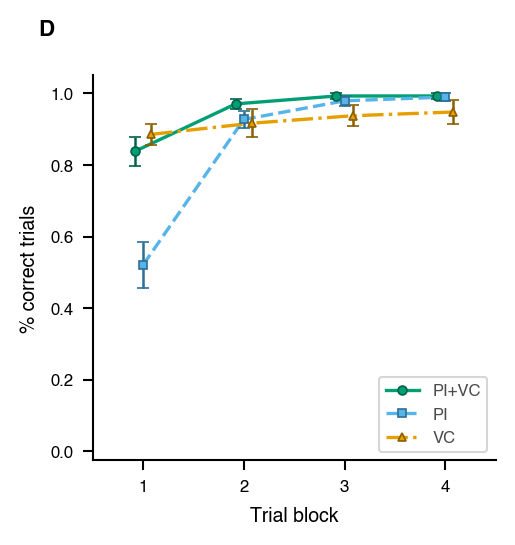

In [16]:
# Panel 2D — block accuracy (function form)
from matplotlib.lines import Line2D

def panel_d(ax,
            # Line / marker / errorbar geometry
            line_lw=1.2, marker_size=STYLE_CFG['marker_size'],
            marker_edge_lw=STYLE_CFG['marker_edge_lw_d'],
            cap_size=STYLE_CFG['cap_size'], err_lw=STYLE_CFG['err_lw'],
            group_offset=0.08, error_kind='sem',
            # Axes
            xlim=(0.5, 4.5), xticks=None, xlabel='Trial block',
            ylim=(-0.025, 1.05), yticks=None, ylabel='% correct trials',
            # Annotation above block 1: None = use D_BLOCK1_STAR from the post hoc cell
            # (falls back to no mark if that cell has not run yet); '' = no mark.
            star_text=None, star_x=1, star_y=1.02,
            star_fontsize=STYLE_CFG['star_fontsize'],
            # Legend
            show_legend=True, legend_loc='lower right',
            legend_fontsize=None, legend_handletextpad=0.8,
            legend_borderpad=0.4, legend_bbox_to_anchor=None,
            legend_top_y=None,
            # Data source: None -> Panel D globals (block_acc / GROUP_ORDER).
            # Panel G4 passes its own frame + groups; `labels` maps group -> legend text.
            data=None, groups=None, labels=None):
    """Panel 2D: block accuracy on criterion session."""
    block_ = block_acc if data is None else data
    groups = GROUP_ORDER if groups is None else list(groups)
    labels = {} if labels is None else labels
    centered_offsets = {
        g: (i - (len(groups) - 1) / 2) * group_offset
        for i, g in enumerate(groups)
    }
    for g in groups:
        st = STYLE[g]
        d = block_[block_['group'] == g]
        offset = centered_offsets[g]
        if error_kind == 'iqr':
            summary = d.groupby('block', observed=True)['pct_correct'].agg(
                center='median', lo=lambda x: x.quantile(0.25), hi=lambda x: x.quantile(0.75)
            ).reset_index()
        else:
            summary = d.groupby('block', observed=True)['pct_correct'].agg(
                center='mean', sem=lambda x: x.std(ddof=1) / (len(x)**0.5)
            ).reset_index()
            summary['lo'] = summary['center'] - summary['sem']
            summary['hi'] = summary['center'] + summary['sem']
        x = summary['block'].values + offset
        y = summary['center'].values
        err_lower = y - summary['lo'].values
        err_upper = summary['hi'].values - y
        ax.plot(x, y, color=st['base'], linestyle=st['line'], linewidth=line_lw, zorder=3)
        ax.errorbar(x, y, yerr=[err_lower, err_upper],
                    fmt=st['marker'], markersize=marker_size,
                    markerfacecolor=st['base'], markeredgecolor=st['edge'],
                    markeredgewidth=marker_edge_lw,
                    ecolor=st['edge'], elinewidth=err_lw, capsize=cap_size, capthick=err_lw,
                    linestyle='none', zorder=4, label=labels.get(g, g))

    if star_text is None:
        star_text = globals().get('D_BLOCK1_STAR', '')
    if star_text:
        ax.text(star_x, star_y, star_text, ha='center', va='bottom', fontsize=star_fontsize)

    if xticks is None:
        xticks = [1, 2, 3, 4]
    ax.set_xticks(xticks)
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)

    ax.set_ylim(*ylim)
    if yticks is None:
        yticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        handles = [Line2D([], [], color=STYLE[g]['base'], linestyle=STYLE[g]['line'],
                          linewidth=line_lw, marker=STYLE[g]['marker'],
                          markerfacecolor=STYLE[g]['base'], markeredgecolor=STYLE[g]['edge'],
                          markeredgewidth=marker_edge_lw, markersize=marker_size,
                          label=labels.get(g, g))
                   for g in groups]
        # Shorthand: legend_top_y anchors the legend's top edge at this axes-fraction y.
        # Horizontal half of legend_loc picks the anchor x (left/right/center).
        # An explicit legend_bbox_to_anchor wins over legend_top_y.
        eff_loc, eff_bbox = legend_loc, legend_bbox_to_anchor
        if legend_top_y is not None and eff_bbox is None:
            ll = legend_loc.lower()
            if 'right' in ll:
                anchor_x, h = 1.0, 'right'
            elif 'left' in ll:
                anchor_x, h = 0.0, 'left'
            else:
                anchor_x, h = 0.5, 'center'
            eff_loc = f'upper {h}'
            eff_bbox = (anchor_x, legend_top_y)
        leg_kwargs = dict(loc=eff_loc, frameon=True,
                          handletextpad=legend_handletextpad,
                          borderpad=legend_borderpad)
        if legend_fontsize is not None:
            leg_kwargs['fontsize'] = legend_fontsize
        if eff_bbox is not None:
            leg_kwargs['bbox_to_anchor'] = eff_bbox
        leg = ax.legend(handles=handles, **leg_kwargs)
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

# Standalone preview
_fig, _ax = plt.subplots(figsize=(2.6, 2.5))
panel_d(_ax)
_fig.text(0.02, 0.96, 'D', fontsize=8, fontweight='bold')
plt.show()


### Mixed-ANOVA helper — afex (Type 3) + sphericity rule

`mixed_anova_afex(df, dv, label=...)` runs the one-within × one-between mixed ANOVAs of this
notebook (Panels 2D and 2F) through R's `afex::aov_ez` (Type 3), printing Mauchly's test, the
GG/HF epsilons, uncorrected and GG-corrected df side by side, and a *Reported* line that follows
the knob `GG_RULE` (`'mauchly'` = Greenhouse–Geisser df only where Mauchly's test rejects at
`GG_ALPHA`; `'always'`; `'never'`). Panels 2E and 2G (two within factors / intercept term) keep
their own `aov_ez` calls and print the same Mauchly output. pingouin's `mixed_anova` is no longer
used for these tests: its ε is estimated from the total covariance (biased low when there is an
interaction) and its within-factor main-effect F is the weighted-means version, which differs from
Type 3 with unequal group sizes (that is why the 2F side F is 43.15 here vs 37.00 in pingouin).

In [17]:
# ============================================================================
# Mixed-ANOVA helper: afex::aov_ez (Type 3) + sphericity rule
# ============================================================================
# Every repeated-measures ANOVA in this notebook runs through R's afex::aov_ez
# (Type 3 sums of squares, sum-to-zero contrasts), so all manuscript values
# come from one convention. afex estimates Mauchly's W and the Greenhouse-
# Geisser / Huynh-Feldt epsilons from the covariance pooled WITHIN groups (as
# SPSS and car do). pingouin's mixed_anova is not used for these tests: its
# epsilon comes from the total subject x block covariance (group mean
# differences included), so it runs low whenever there is a block x group
# interaction, and its within-factor main-effect F uses weighted marginal
# means, which differs from Type 3 when group sizes are unequal (the group and
# interaction F agree to the decimal).
#
# Sphericity rule (knob): which df the "Reported" line carries for the within
# factor and its interaction with group.
#   'mauchly' -> Greenhouse-Geisser df when Mauchly's p < GG_ALPHA, else uncorrected
#   'always'  -> Greenhouse-Geisser df for every within term
#   'never'   -> uncorrected df
GG_RULE = 'mauchly'
GG_ALPHA = 0.05
MIXED_STATS = {}   # label -> table returned by mixed_anova_afex (for reports / captions)

from scipy import stats
try:
    from rpy2.robjects import r as _r, pandas2ri as _pandas2ri, globalenv as _globalenv
    from rpy2.robjects import default_converter as _default_converter
    from rpy2.robjects.conversion import localconverter as _localconverter
    from rpy2.robjects.packages import importr as _importr
    _importr('afex')
    HAS_AFEX = True
except Exception as _err:   # R / afex / rpy2 missing in this kernel
    HAS_AFEX = False
    print(f'afex unavailable ({_err!r}); mixed_anova_afex will raise until R + afex + rpy2 are installed.')


def fmt_p(p):
    """Manuscript p format: 'p < .001'; three decimals below .10, two otherwise, no leading zero."""
    if p < .001:
        return 'p < .001'
    s = f'{p:.3f}' if p < .10 else f'{p:.2f}'
    return 'p = ' + s.lstrip('0')


def fmt_F(F, df1, df2):
    """F(df1, df2) = F; integer df print as integers, corrected df as 2 / 1 decimals."""
    if float(df1).is_integer() and float(df2).is_integer():
        return f'F({int(df1)}, {int(df2)}) = {F:.2f}'
    return f'F({df1:.2f}, {df2:.1f}) = {F:.2f}'


def _afex_mixed(d, *, dv, within, between, subject, between_levels, within_levels):
    """Fit afex::aov_ez on `d` (columns subject/between/within/dv, all strings but dv);
    return the uncorrected ANOVA table with Mauchly W/p and the GG/HF epsilons as columns."""
    lv_b = ', '.join(f"'{x}'" for x in between_levels)
    lv_w = ', '.join(f"'{x}'" for x in within_levels)
    code = f"""
    .d${subject} <- factor(.d${subject})
    .d${between} <- factor(.d${between}, levels = c({lv_b}))
    .d${within}  <- factor(.d${within},  levels = c({lv_w}))
    .fit <- afex::aov_ez(id = '{subject}', dv = '{dv}', within = '{within}', between = '{between}',
                         data = .d, anova_table = list(correction = 'none', es = 'pes'))
    .s   <- summary(.fit)
    .tab <- as.data.frame(.fit$anova_table)
    .tab$term <- rownames(.tab)
    .m <- .s$sphericity.tests
    .e <- .s$pval.adjustments
    if (is.null(.m) || nrow(.m) == 0) {{
      .tab$W <- NA_real_; .tab$p_mauchly <- NA_real_; .tab$eps_gg <- 1; .tab$eps_hf <- 1
      .tab$p_gg <- NA_real_; .tab$p_hf <- NA_real_
    }} else {{
      .tab$W <- .m[1, 1]; .tab$p_mauchly <- .m[1, 2]; .tab$eps_gg <- .e[1, 1]; .tab$eps_hf <- .e[1, 3]
      .i <- match(rownames(.tab), rownames(.e))
      .tab$p_gg <- .e[.i, 2]; .tab$p_hf <- .e[.i, 4]
    }}
    .tab
    """
    with _localconverter(_default_converter + _pandas2ri.converter):
        _globalenv['.d'] = d
        tab = _r(code)
    return tab


def mixed_anova_afex(df, dv, *, label, within='block', between='group', subject='subject_id',
                     between_levels=None, quiet=False):
    """Mixed ANOVA (one within factor x one between factor) via afex::aov_ez, Type 3.

    Prints Mauchly's test, the epsilons, the uncorrected table with the GG-corrected df
    and p alongside, and the 'Reported' line that follows GG_RULE. Returns a pingouin-
    style DataFrame (Source = between / within / 'Interaction'; DF1, DF2, F, p_unc, np2)
    with extra columns: eps, W_spher, p_spher, DF1_gg, DF2_gg, p_GG_corr, corrected,
    DF1_rep, DF2_rep, p_rep (the reported version) and `reported` (the sentence).
    The table is also stored in MIXED_STATS[label]."""
    if not HAS_AFEX:
        raise RuntimeError('afex is unavailable in this kernel')
    d = df[[subject, between, within, dv]].dropna(subset=[dv]).copy()
    for c in (subject, between, within):
        d[c] = d[c].astype(str)
    if between_levels is None:
        _present = set(d[between])
        between_levels = [g for g in GROUP_ORDER if g in _present] + sorted(_present - set(GROUP_ORDER))
    within_levels = sorted(d[within].unique(), key=lambda v: (len(v), v))
    tab = _afex_mixed(d, dv=dv, within=within, between=between, subject=subject,
                      between_levels=between_levels, within_levels=within_levels)
    src = [between if t == between else within if t == within else 'Interaction' for t in tab['term']]
    out = pd.DataFrame({'Source': src,
                        'DF1': np.rint(tab['num Df'].astype(float).values).astype(int),
                        'DF2': np.rint(tab['den Df'].astype(float).values).astype(int),
                        'F': tab['F'].astype(float).values,
                        'p_unc': tab['Pr(>F)'].astype(float).values,
                        'np2': tab['pes'].astype(float).values,
                        'MSE': tab['MSE'].astype(float).values})
    eps = float(tab['eps_gg'].iloc[0]); eps_hf = float(tab['eps_hf'].iloc[0])
    W = float(tab['W'].iloc[0]); p_m = float(tab['p_mauchly'].iloc[0])
    is_within = (out['Source'] != between).to_numpy()
    if GG_RULE == 'always':
        use_gg = True
    elif GG_RULE == 'never':
        use_gg = False
    elif GG_RULE == 'mauchly':
        use_gg = (not np.isnan(p_m)) and p_m < GG_ALPHA
    else:
        raise ValueError(f'GG_RULE must be mauchly / always / never, got {GG_RULE!r}')
    out['eps'] = eps; out['eps_hf'] = eps_hf; out['W_spher'] = W; out['p_spher'] = p_m
    _has_sph = is_within & (not np.isnan(p_m))   # no GG df when the within factor has 2 levels
    out['DF1_gg'] = np.where(_has_sph, out['DF1'] * eps, np.nan)
    out['DF2_gg'] = np.where(_has_sph, out['DF2'] * eps, np.nan)
    out['p_GG_corr'] = tab['p_gg'].astype(float).values
    out['corrected'] = is_within & use_gg
    out['DF1_rep'] = np.where(out['corrected'], out['DF1_gg'], out['DF1'])
    out['DF2_rep'] = np.where(out['corrected'], out['DF2_gg'], out['DF2'])
    out['p_rep'] = np.where(out['corrected'], out['p_GG_corr'], out['p_unc'])
    _name = {between: between, within: within, 'Interaction': f'{within} × {between}'}
    reported = '; '.join(f"{_name[s]} {fmt_F(F, d1, d2)}, {fmt_p(p)}"
                         for s, F, d1, d2, p in zip(out['Source'], out['F'], out['DF1_rep'], out['DF2_rep'], out['p_rep']))
    out.attrs['reported'] = reported
    out.attrs['label'] = label
    MIXED_STATS[label] = out
    if not quiet:
        k_w, k_b = len(within_levels), len(between_levels)
        print(f'=== {label}: {k_w} x {k_b} mixed ANOVA ({within} within × {between} between), '
              f'afex::aov_ez Type 3; n = {d[subject].nunique()} ===')
        if np.isnan(p_m):
            print(f"Mauchly's test: not applicable ({k_w} within levels); no sphericity correction")
        else:
            print(f"Mauchly's test on {within}: W = {W:.3f}, p = {p_m:.4g} -> "
                  f"{'sphericity violated' if p_m < GG_ALPHA else 'sphericity not rejected'}; "
                  f"GG eps = {eps:.3f}, HF eps = {eps_hf:.3f}")
        rows = []
        for _, r_ in out.iterrows():
            rows.append({'Source': r_['Source'], 'F': f"{r_['F']:.2f}",
                         'df (unc)': f"{r_['DF1']}, {r_['DF2']}", 'p (unc)': f"{r_['p_unc']:.4g}",
                         'df (GG)': '-' if np.isnan(r_['DF1_gg']) else f"{r_['DF1_gg']:.2f}, {r_['DF2_gg']:.1f}",
                         'p (GG)': '-' if np.isnan(r_['p_GG_corr']) else f"{r_['p_GG_corr']:.4g}",
                         'np2': f"{r_['np2']:.3f}"})
        print(pd.DataFrame(rows).to_string(index=False))
        _rule = f"GG_RULE = '{GG_RULE}' -> {'GG df' if use_gg else 'uncorrected df'}"
        print(f'Reported ({_rule}): {reported}')
    return out

### Panel 2D assumption checks

For a 4×3 mixed ANOVA, three assumptions matter:

- **Normality of residuals** (Shapiro–Wilk per cell, or on residuals) — want p > .05
- **Homogeneity of variance** between groups (Levene) — want p > .05
- **Sphericity** of the within-subjects factor (Mauchly's test on `block`, from afex, i.e. the covariance pooled within groups) — want p > .05; if violated, the within-subject terms are reported with Greenhouse–Geisser df (`GG_RULE = 'mauchly'`)

In [18]:
# Panel 2D — assumption checks
import pingouin as pg

# 1) Normality per group×block cell
print('Shapiro-Wilk normality per group×block cell:')
norm = (
    block_acc.groupby(['group', 'block'], observed=True)['pct_correct']
    .apply(lambda x: stats.shapiro(x).pvalue if x.nunique() > 1 else 1.0)
    .reset_index(name='shapiro_p')
)
print(norm.pivot(index='block', columns='group', values='shapiro_p').round(3).loc[:, GROUP_ORDER])
print()

# 2) Levene by block (homogeneity of variance across groups)
print('Levene (variance across groups) per block:')
for b in [1, 2, 3, 4]:
    arrs = [block_acc.loc[(block_acc['group']==g) & (block_acc['block']==b), 'pct_correct'].values
            for g in GROUP_ORDER]
    L, p = stats.levene(*arrs, center='median')
    flag = '' if p > .05 else '  ← variances differ'
    print(f'  block {b}:  W = {L:.2f}, p = {p:.3f}{flag}')
print()

# 3) Mauchly's sphericity for the within-subjects factor (block), from afex
#    (covariance pooled within groups). pingouin's pg.sphericity uses the total
#    covariance, which overstates the violation when group profiles differ.
_sph = mixed_anova_afex(block_acc, 'pct_correct', label='2D block accuracy (sphericity check)', quiet=True)
print("Mauchly's sphericity test on `block` (afex):")
print(f"  W = {_sph['W_spher'].iloc[0]:.3f}, p = {_sph['p_spher'].iloc[0]:.4g}, GG eps = {_sph['eps'].iloc[0]:.3f}"
      f"{'' if _sph['p_spher'].iloc[0] > GG_ALPHA else '  ← Greenhouse-Geisser df on the within terms (GG_RULE)'}")

R callback write-console: Contrasts set to contr.sum for the following variables: group
  


Shapiro-Wilk normality per group×block cell:
group  PI+VC     PI     VC
block                     
1      0.007  0.519  0.018
2      0.000  0.004  0.001
3      0.000  0.000  0.000
4      0.000  0.000  0.000

Levene (variance across groups) per block:
  block 1:  W = 2.04, p = 0.144
  block 2:  W = 1.77, p = 0.184
  block 3:  W = 2.80, p = 0.073
  block 4:  W = 1.82, p = 0.176

Mauchly's sphericity test on `block` (afex):
  W = 0.480, p = 5.96e-05, GG eps = 0.656  ← Greenhouse-Geisser df on the within terms (GG_RULE)


### Panel 2D — 4×3 mixed ANOVA

Reproduces the manuscript test:

- Within-subjects factor: **block** (4 levels)
- Between-subjects factor: **group** (3 levels)

**Manuscript values:** main effect of group F(2, 39) = 9.3, p < .001; block × group interaction F(6, 117) = 14.3, p < .001.

**Rebuilt values (N = 41):** group F(2, 38) = 8.79, p < .001; block × group interaction F(6, 114) = 12.29, p < .001 — same conclusions as the manuscript, but the F-magnitudes run lower and are not reproducible in either pingouin or R (`afex`/`ez` agree with pingouin to the decimal), indicating the manuscript's printed values came from different software. Sphericity is violated for `block` (Mauchly W = 0.48, p < .001, afex). The table below is `afex::aov_ez` (Type 3) via `mixed_anova_afex`; under `GG_RULE = 'mauchly'` the within terms are reported with Greenhouse–Geisser df (ε = 0.66, from the pooled within-group covariance; pingouin's ε = 0.51 is computed from the total covariance and runs low when there is an interaction): block × group **F(3.94, 74.8) = 12.29, p < .001**.

In [19]:
# 4 x 3 mixed ANOVA: block (within) x group (between), afex::aov_ez (Type 3), with
# Mauchly's test and the GG_RULE decision printed by the helper. Mauchly rejects
# (W = .48, p < .001; eps = .66), so the reported within terms carry Greenhouse-
# Geisser df: block x group F(3.94, 74.8) = 12.29, p < .001 (the manuscript value).
# pingouin's mixed_anova is not used: its epsilon (.51) comes from the total
# covariance and runs low when there is an interaction; its group and interaction
# F agree with afex to the decimal.
aov = mixed_anova_afex(block_acc, 'pct_correct', label='2D block accuracy')


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 2D block accuracy: 4 x 3 mixed ANOVA (block within × group between), afex::aov_ez Type 3; n = 41 ===
Mauchly's test on block: W = 0.480, p = 5.96e-05 -> sphericity violated; GG eps = 0.656, HF eps = 0.692
     Source     F df (unc)   p (unc)    df (GG)    p (GG)   np2
      group  8.79    2, 38 0.0007292          -         - 0.316
      block 43.69   3, 114  7.17e-19 1.97, 74.8 3.503e-13 0.535
Interaction 12.29   6, 114 1.242e-10 3.94, 74.8 1.147e-07 0.393
Reported (GG_RULE = 'mauchly' -> GG df): group F(2, 38) = 8.79, p < .001; block F(1.97, 74.8) = 43.69, p < .001; block × group F(3.94, 74.8) = 12.29, p < .001


### Post-hoc — pairwise group comparisons within each block

The manuscript ran Bonferroni-corrected post hoc tests within each block, finding that PI was significantly worse than the other groups **only in block 1** (p < .001), with no group differences in blocks 2–4 (p ≥ .17).

In [20]:
# Pairwise group comparisons within each block, Bonferroni-corrected
ph = pg.pairwise_tests(
    data=block_acc, dv='pct_correct',
    within='block', between='group', subject='subject_id',
    padjust='bonf',
).query('Contrast == "block * group"')
print(ph[['block','A','B','T','dof','p_unc','p_corr','hedges']].round(3).to_string(index=False))

# Mark drawn above block 1 in Panel D: the larger Bonferroni-corrected p of the two PI
# contrasts at block 1 (PI vs PI+VC, PI vs VC), so the mark summarises 'PI below both'.
_b1 = ph[(ph['block'].astype(str) == '1') & ((ph['A'] == 'PI') | (ph['B'] == 'PI'))]
D_BLOCK1_P = float(_b1['p_corr'].max())
D_BLOCK1_STAR = ('***' if D_BLOCK1_P < .001 else '**' if D_BLOCK1_P < .01
                 else '*' if D_BLOCK1_P < .05 else '\u2020' if D_BLOCK1_P < .10 else 'ns')
print(f"\nPanel D block-1 mark: larger corrected p of the PI contrasts = {D_BLOCK1_P:.4f} -> '{D_BLOCK1_STAR}'")


block     A     B      T    dof  p_unc  p_corr  hedges
    1    PI PI+VC -4.126 19.456  0.001   0.007  -1.588
    1    PI    VC -5.135 22.000  0.000   0.000  -2.024
    1 PI+VC    VC -0.941 26.271  0.355   1.000  -0.316
    2    PI PI+VC -1.580 17.545  0.132   1.000  -0.622
    2    PI    VC  0.228 22.000  0.822   1.000   0.090
    2 PI+VC    VC  1.317 13.601  0.209   1.000   0.549
    3    PI PI+VC -0.850 16.979  0.407   1.000  -0.337
    3    PI    VC  1.301 22.000  0.207   1.000   0.513
    3 PI+VC    VC  1.856 12.446  0.087   1.000   0.791
    4    PI PI+VC -0.240 21.093  0.812   1.000  -0.091
    4    PI    VC  1.221 22.000  0.235   1.000   0.481
    4 PI+VC    VC  1.343 12.134  0.204   1.000   0.576

Panel D block-1 mark: larger corrected p of the PI contrasts = 0.0066 -> '**'


## Panel 2E — 1st choice vs 2nd choice accuracy over last 5 acquisition sessions

The manuscript reports that accuracy is higher at the 2nd choice point than the 1st, and that this advantage narrows across sessions. The design is a **2 × 5 × 3 mixed ANOVA**: choice point (1st / 2nd) × session (1–5) × group (PI+VC / PI / VC), with two within factors and one between. Because `pingouin.mixed_anova` only handles one within factor, we call **`afex::aov_ez`** in R via `rpy2` for this test.

**2nd choice definition:** the 2nd choice is scored correct when the rat's actual 2nd turn matches the 2nd turn of the direct-to-goal route (`actual_route[1] == correct_route[1]`), computed on **all** trials regardless of side. Because the correct 2nd turn is a constant response per rat, this credits the trained 2nd response wherever the rat makes it — including on non-goal-side trials after a wrong 1st choice (where the trained turn points away from the goal). This is the "habitual response regardless of side" measure and matches the original MATLAB `acq_choice2` (`goal_seek_action(3) == SecondCorrect`). Fig 2F applies this same trained-response measure but splits it by whether the 2nd turn occurred on the goal-side or non-goal-side arm.

**Cohort filter:** only rats that required ≥5 acquisition sessions to reach criterion. The rebuilt pipeline yields **PI+VC n=15, PI n=10, VC n=12** (the manuscript reports PI+VC n=14; one extra PI+VC rat clears ≥5 sessions here, traceable to session-merge handling). Fast learners without 5 sessions of data are excluded.

**Trial filter:** the first 8 trials (the first block) of each session are excluded for **all groups**, to accommodate the fact that PI rats lack directional orientation during the first block (Fig 2D). This uniform exclusion matches the manuscript text; it differs from the original MATLAB code, which dropped only the first 2 trials and only for PI (see `docs/matlab_2E_analysis_notes.md`).

### Panel 2E data — per-rat × session × choice-point accuracy

- **1st-choice correct** = `actual_route[0] == correct_route[0]`  (did the rat turn toward the goal side?)
- **2nd-choice correct** = `actual_route[1] == correct_route[1]`  (did the rat's 2nd turn match the direct-to-goal route's 2nd turn?)

The 2nd choice compares the rat's actual 2nd turn to the correct one-shot route's 2nd turn on every trial. On 1st-correct trials this equals the goal-directed turn; on 1st-wrong (non-goal-side) trials it credits the trained/constant response (the habit) rather than the goal-directed turn. This matches the original MATLAB `acq_choice2` convention.

In [21]:
# Build trial-level 1st and 2nd choice correctness
def _char_at(route, idx):
    s = route if isinstance(route, str) else ''
    return s[idx] if len(s) > idx else None

acq_trials_e = trials[trials['session_experiment_phase'] == 'Acquisition'].copy()
acq_trials_e['c1_actual']  = acq_trials_e['actual_route'].apply(lambda r: _char_at(r, 0))
acq_trials_e['c1_correct'] = acq_trials_e['correct_route'].apply(lambda r: _char_at(r, 0))
acq_trials_e['first_ok']  = (acq_trials_e['c1_actual'] == acq_trials_e['c1_correct']).astype(int)

# 2nd choice: did the actual 2nd turn match the direct-to-goal route's 2nd turn?
# (the trained/constant 2nd response, scored on ALL trials regardless of side —
#  equals the original MATLAB acq_choice2 = goal_seek_action(3) == SecondCorrect)
ar1 = acq_trials_e['actual_route'].apply(lambda r: _char_at(r, 1))
cr1 = acq_trials_e['correct_route'].apply(lambda r: _char_at(r, 1))
acq_trials_e['second_ok'] = (ar1 == cr1).astype(float)
# NaN where either turn is undefined
acq_trials_e.loc[ar1.isna() | cr1.isna(), 'second_ok'] = np.nan

# Attach session-from-start rank and filter to last 5 sessions per rat
n_per_rat = acq_sessions.groupby('subject_id', observed=True).size().rename('n_acq')
eligible = n_per_rat[n_per_rat >= 5].index
acq_trials_e = acq_trials_e.merge(
    acq_sessions[['session_id','session_rank_desc']], on='session_id', how='inner'
)
acq_trials_e['group'] = acq_trials_e['subject_id'].map(subj_to_group)

# Filter to last 5 sessions, drop the first 8 trials (first block) of each session for ALL groups
last5 = acq_trials_e[
    acq_trials_e['subject_id'].isin(eligible)
    & (acq_trials_e['session_rank_desc'] <= 4)
    & (acq_trials_e['trial_number'] > 8)
].copy()

last5['session_number'] = 5 - last5['session_rank_desc'].astype(int)

# Check for trials with an undefined 2nd turn
n_missing_2nd = last5['second_ok'].isna().sum()
if n_missing_2nd:
    print(f'  note: {n_missing_2nd} trials with an undefined 2nd turn — dropped from 2nd-choice means')

# Aggregate to per-rat × session × choice-point
per = (
    last5.groupby(['group','subject_id','session_number'], observed=True)
    .agg(first=('first_ok','mean'), second=('second_ok','mean'))
    .reset_index()
)
long = per.melt(
    id_vars=['group','subject_id','session_number'],
    value_vars=['first','second'],
    var_name='choice_point', value_name='pct_correct',
)
long['choice_point'] = long['choice_point'].map({'first':'1st','second':'2nd'})

print('Rats included per group (manuscript: PI+VC n=14, PI n=10, VC n=12):')
print(long.groupby('group', observed=True)['subject_id'].nunique().loc[GROUP_ORDER])
print()
print('Per-group median accuracy by session × choice point:')
print(
    long.pivot_table(index='session_number', columns=['group','choice_point'],
                     values='pct_correct', aggfunc='median', observed=True)
    .round(2)
)

Rats included per group (manuscript: PI+VC n=14, PI n=10, VC n=12):
group
PI+VC    15
PI       10
VC       12
Name: subject_id, dtype: int64

Per-group median accuracy by session × choice point:
group             PI       PI+VC          VC      
choice_point     1st   2nd   1st   2nd   1st   2nd
session_number                                    
1               0.48  0.56  0.73  0.93  0.62  0.81
2               0.69  0.81  0.79  1.00  0.60  0.89
3               0.70  0.95  0.95  1.00  0.63  1.00
4               0.90  1.00  1.00  1.00  0.92  1.00
5               0.94  1.00  1.00  1.00  0.92  1.00


### Panel 2E — 2 × 5 × 3 mixed ANOVA via R (afex)

Because pingouin only handles one within factor, we call `afex::aov_ez` through `rpy2`. Two within factors (`choice_point`, `session_number`) plus one between (`group`). afex applies Type III SS and Greenhouse–Geisser correction by default.

**Manuscript values** (goal-side 2nd-choice measure, reported from SPSS; not reproducible in afex/pingouin even from the legacy MATLAB per-session scores — see `docs/matlab_2E_analysis_notes.md`):
- main effect of session: F(4, 132) = 19.9, p < .001
- main effect of choice point: F(1, 33) = 71.1, p < .001
- session × choice point: F(4, 132) = 40.8, p < .001

**Rebuilt values** (N=37, first-8-all-groups filter, trained-2nd-turn measure, uncorrected df): choice point F(1,34) = 84.2, p < .001 (2nd > 1st); session F(4,136) = 43.4, p < .001; session × choice-point F(4,136) = 4.31, p = .003 (the 2nd-over-1st advantage narrows across sessions). The group × choice-point interaction is significant (F(2,34) = 4.29, p = .022): the advantage is present in all groups but differs in size (largest in VC). The GG-corrected table below (session and interaction) reaches the same conclusions (interaction p = .011).

In [22]:
# 2 x 5 x 3 mixed ANOVA via R's afex::aov_ez
from rpy2.robjects import r, pandas2ri, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects.packages import importr

importr('afex')

# Local converter: auto-converts pandas <-> R data.frames inside the block.
with localconverter(default_converter + pandas2ri.converter):
    r_df = long.copy()
    r_df['subject_id']     = r_df['subject_id'].astype(str)
    r_df['session_number'] = r_df['session_number'].astype(str)
    globalenv['df'] = r_df   # auto-converts to R data.frame

    r_code = """
    df$subject_id     <- factor(df$subject_id)
    df$session_number <- factor(df$session_number, levels = as.character(1:5))
    df$choice_point   <- factor(df$choice_point, levels = c('1st','2nd'))
    df$group          <- factor(df$group, levels = c('PI+VC','PI','VC'))

    fit <- afex::aov_ez(
      id = 'subject_id', dv = 'pct_correct',
      within = c('choice_point','session_number'),
      between = 'group',
      data = df,
      anova_table = list(correction = 'GG', es = 'pes')
    )
    fit$anova_table
    """
    aov_df = r(r_code)   # already a pandas DataFrame inside the converter context

print('2 x 5 x 3 mixed ANOVA (afex::aov_ez, Greenhouse-Geisser):')
print(aov_df.round(4).to_string())

# Sphericity (afex summary: Mauchly's test and the GG / HF epsilons per within term).
# Both session terms reject, so the GG df in the table above are the reported ones.
print("\nMauchly's tests and epsilons (afex summary):")
print('\n'.join(list(r('capture.output(print(summary(fit)$sphericity.tests))'))))
print('\n'.join(list(r('capture.output(print(summary(fit)$pval.adjustments))'))))


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


2 x 5 x 3 mixed ANOVA (afex::aov_ez, Greenhouse-Geisser):
                                   num Df   den Df     MSE        F     pes  Pr(>F)
group                              2.0000  34.0000  0.0336  16.4362  0.4916  0.0000
choice_point                       1.0000  34.0000  0.0159  84.2220  0.7124  0.0000
group:choice_point                 2.0000  34.0000  0.0159   4.2938  0.2016  0.0217
session_number                     1.9182  65.2201  0.0498  43.3934  0.5607  0.0000
group:session_number               3.8365  65.2201  0.0498   2.0551  0.1079  0.0996
choice_point:session_number        2.4668  83.8701  0.0179   4.3069  0.1124  0.0111
group:choice_point:session_number  4.9335  83.8701  0.0179   2.2087  0.1150  0.0617

Mauchly's tests and epsilons (afex summary):
                                  Test statistic    p-value
session_number                          0.085203 0.0000e+00
group:session_number                    0.085203 0.0000e+00
choice_point:session_number             0.23

In [23]:
# Post-hoc: per-group × session paired t-tests (1st vs 2nd choice accuracy)
# Bonferroni-corrected within each group (5 tests per group)
from scipy import stats

raw_results = {}
for g in GROUP_ORDER:
    for sn in range(1, 6):
        d = per[(per['group'] == g) & (per['session_number'] == sn)]
        if len(d) < 3:
            continue
        t_stat, p_val = stats.ttest_rel(d['first'], d['second'])
        raw_results[(g, sn)] = {'t': t_stat, 'p_raw': p_val}

# Count tests per group for within-group Bonferroni
tests_per_group = {}
for (g, sn) in raw_results:
    tests_per_group[g] = tests_per_group.get(g, 0) + 1

posthoc_results = {}
for (g, sn), vals in raw_results.items():
    p_corr = min(vals['p_raw'] * tests_per_group[g], 1.0)
    posthoc_results[(g, sn)] = p_corr

def sig_stars(p):
    if pd.isna(p):    return 'na'
    if p < 0.001:     return '***'
    if p < 0.01:      return '**'
    if p < 0.05:      return '*'
    if p < 0.1:       return '†'
    return 'ns'

# Sort: significant first, then na, then ns
def _sort_key(item):
    g, sn = item[0]
    p = item[1]
    if pd.isna(p):       rank = 1   # na above ns
    elif p >= 0.05:      rank = 2   # ns last
    else:                rank = 0   # significant first
    return (GROUP_ORDER.index(g), rank, sn)

print("Post-hoc paired t-tests (1st vs 2nd choice), Bonferroni-corrected within group (n=5 per group):")
for (g, sn), p_corr in sorted(posthoc_results.items(), key=_sort_key):
    p_raw = raw_results[(g, sn)]['p_raw']
    p_raw_str = f'{p_raw:.4f}' if not pd.isna(p_raw) else '    na'
    p_corr_str = f'{p_corr:.4f}' if not pd.isna(p_corr) else '    na'
    print(f"  {g:8s} session {sn}: p_raw = {p_raw_str}, p_corr = {p_corr_str} {sig_stars(p_corr)}")

Post-hoc paired t-tests (1st vs 2nd choice), Bonferroni-corrected within group (n=5 per group):
  PI+VC    session 1: p_raw = 0.0003, p_corr = 0.0014 **
  PI+VC    session 2: p_raw = 0.0005, p_corr = 0.0024 **
  PI+VC    session 3: p_raw = 0.0044, p_corr = 0.0218 *
  PI+VC    session 4: p_raw = 0.0263, p_corr = 0.1317 ns
  PI+VC    session 5: p_raw = 0.0135, p_corr = 0.0676 †
  PI       session 5: p_raw = 0.0095, p_corr = 0.0473 *
  PI       session 1: p_raw = 0.5042, p_corr = 1.0000 ns
  PI       session 2: p_raw = 0.2838, p_corr = 1.0000 ns
  PI       session 3: p_raw = 0.0136, p_corr = 0.0682 †
  PI       session 4: p_raw = 0.0149, p_corr = 0.0746 †
  VC       session 2: p_raw = 0.0013, p_corr = 0.0063 **
  VC       session 3: p_raw = 0.0001, p_corr = 0.0004 ***
  VC       session 4: p_raw = 0.0089, p_corr = 0.0446 *
  VC       session 5: p_raw = 0.0098, p_corr = 0.0490 *
  VC       session 1: p_raw = 0.0275, p_corr = 0.1375 ns


### Panel 2E — planned per-group contrasts (1st vs 2nd choice, averaged across sessions)

The per-session post-hoc grid above tests 15 cells and only reaches significance for PI at session 5. The planned comparison the manuscript actually needs is one per group: each rat's 1st- and 2nd-choice accuracy averaged over the five sessions, compared with a paired t-test (3 planned contrasts; raw p reported, Bonferroni ×3 for reference; Wilcoxon, Cohen's d_z and BF10 as checks). The group difference in the 2nd−1st advantage is then a one-way ANOVA on the per-rat difference scores, which is identical to the group × choice-point interaction in the mixed ANOVA.

**Result.** 2nd > 1st in every group: PI+VC +8.8 pts, t(14) = 6.68, p < .001, d_z = 1.72; PI +10.3 pts, t(9) = 4.03, p = .003, d_z = 1.28; VC +17.5 pts, t(11) = 5.78, p < .001, d_z = 1.67 (all survive Bonferroni ×3 and Wilcoxon). The size of the advantage differs by group only marginally: F(2,34) = 4.29, p = .022 but Welch p = .058, and no pairwise contrast survives Holm (PI+VC vs VC p = .056).

**Group main effect follow-up.** The manuscript attributes the group main effect (F(2, 34) = 16.4) to lower overall accuracy in the PI group. The last block of the next cell tests that directly: each rat's overall accuracy (mean of 1st- and 2nd-choice accuracy averaged over the five sessions, i.e. what the ANOVA's group term averages over) compared across groups with Tukey HSD, with Games–Howell as the unequal-variance check.


In [24]:
# Planned per-group paired comparison: 1st vs 2nd choice accuracy, averaged across the 5 sessions
# (one contrast per group = 3 planned comparisons; raw p reported, Bonferroni x3 shown for reference)
from scipy import stats
import pingouin as pg

rat_avg = (long.groupby(['group', 'subject_id', 'choice_point'], observed=True)['pct_correct']
               .mean().unstack('choice_point').reset_index())
rat_avg['diff'] = rat_avg['2nd'] - rat_avg['1st']

planned_2e = []
for g in ['PI+VC', 'PI', 'VC']:
    d = rat_avg[rat_avg['group'] == g]
    t, p = stats.ttest_rel(d['2nd'], d['1st'])
    n = len(d)
    dz = d['diff'].mean() / d['diff'].std(ddof=1)
    ci = stats.t.interval(0.95, n - 1, loc=d['diff'].mean(), scale=d['diff'].sem())
    w = stats.wilcoxon(d['2nd'], d['1st']).pvalue
    bf10 = float(pg.bayesfactor_ttest(t, n, paired=True))
    planned_2e.append(dict(group=g, n=n, mean_1st=d['1st'].mean(), mean_2nd=d['2nd'].mean(),
                           diff=d['diff'].mean(), ci_lo=ci[0], ci_hi=ci[1], t=t, df=n - 1,
                           p=p, p_bonf3=min(p * 3, 1.0), dz=dz, wilcoxon_p=w, BF10=bf10))
planned_2e = pd.DataFrame(planned_2e)

print('Fig 2E planned paired comparisons, 2nd vs 1st choice accuracy averaged over sessions 1-5:')
for r in planned_2e.itertuples():
    print(f"  {r.group:6s} n={r.n:2d}  1st={r.mean_1st*100:5.1f}%  2nd={r.mean_2nd*100:5.1f}%  "
          f"diff={r.diff*100:+5.1f} pts [95% CI {r.ci_lo*100:+.1f}, {r.ci_hi*100:+.1f}]  "
          f"t({r.df})={r.t:.2f}, p={r.p:.2g} (Bonf x3 {r.p_bonf3:.2g}), dz={r.dz:.2f}, Wilcoxon p={r.wilcoxon_p:.3f}, BF10={r.BF10:.3g}")

# group difference in the (2nd - 1st) advantage = the group x choice-point interaction, on session-averaged scores
aov_diff = pg.anova(data=rat_avg, dv='diff', between='group', detailed=False).iloc[0]
welch_diff = pg.welch_anova(data=rat_avg, dv='diff', between='group').iloc[0]
pu = lambda row: row['p-unc'] if 'p-unc' in row.index else row['p_unc']
print(f"\nDoes the 2nd-choice advantage differ by group?  one-way ANOVA F({int(aov_diff['ddof1'])},{int(aov_diff['ddof2'])})={aov_diff['F']:.2f}, p={pu(aov_diff):.3f};  "
      f"Welch F={welch_diff['F']:.2f}, p={pu(welch_diff):.3f}")
pw = pg.pairwise_tests(data=rat_avg, dv='diff', between='group', padjust='holm')
print(pw[[c for c in pw.columns if c in ('A','B','T','dof','p-unc','p_unc','p-corr','p_corr','hedges')]].round(3).to_string(index=False))

# Group main effect follow-up: per-rat OVERALL accuracy (mean of 1st and 2nd, averaged over sessions)
# = what the mixed ANOVA's group term averages over. Tukey HSD primary; Games-Howell as the
# unequal-variance check. (Manuscript: 'driven by lower overall accuracy scores in the PI group'.)
rat_avg['overall'] = rat_avg[['1st', '2nd']].mean(axis=1)
overall_means = (rat_avg.groupby('group', observed=True)['overall']
                 .agg(['mean', 'sem', 'count']).loc[GROUP_ORDER])
print('\nGroup main effect follow-up - per-rat overall accuracy (mean of 1st and 2nd choice, sessions 1-5):')
print(overall_means.round(3).to_string())
_tk = stats.tukey_hsd(*[rat_avg.loc[rat_avg['group'] == g, 'overall'].to_numpy() for g in GROUP_ORDER])
print('Tukey HSD on overall accuracy:')
for _i, _a in enumerate(GROUP_ORDER):
    for _j, _b in enumerate(GROUP_ORDER):
        if _j > _i:
            print(f'  {_a:6s} vs {_b:6s}: diff = {_tk.statistic[_i, _j]:+.3f}, p = {_tk.pvalue[_i, _j]:.4f}')
gh_overall = pg.pairwise_gameshowell(data=rat_avg, dv='overall', between='group')
print('Games-Howell check:')
print(gh_overall[[c for c in gh_overall.columns if c in ('A', 'B', 'diff', 'pval', 'hedges')]].round(4).to_string(index=False))


Fig 2E planned paired comparisons, 2nd vs 1st choice accuracy averaged over sessions 1-5:
  PI+VC  n=15  1st= 87.3%  2nd= 96.1%  diff= +8.8 pts [95% CI +6.0, +11.6]  t(14)=6.68, p=1.1e-05 (Bonf x3 3.2e-05), dz=1.72, Wilcoxon p=0.001, BF10=2.11e+03
  PI     n=10  1st= 74.1%  2nd= 84.4%  diff=+10.3 pts [95% CI +4.5, +16.1]  t(9)=4.03, p=0.003 (Bonf x3 0.0089), dz=1.28, Wilcoxon p=0.004, BF10=16.7
  VC     n=12  1st= 73.4%  2nd= 90.9%  diff=+17.5 pts [95% CI +10.8, +24.2]  t(11)=5.78, p=0.00012 (Bonf x3 0.00037), dz=1.67, Wilcoxon p=0.001, BF10=241

Does the 2nd-choice advantage differ by group?  one-way ANOVA F(2,34)=4.29, p=0.022;  Welch F=3.35, p=0.058
    A     B      T    dof  p_unc  p_corr  hedges
   PI PI+VC  0.522 13.808  0.610   0.610   0.225
   PI    VC -1.819 19.902  0.084   0.168  -0.731
PI+VC    VC -2.635 15.132  0.019   0.056  -1.063

Group main effect follow-up - per-rat overall accuracy (mean of 1st and 2nd choice, sessions 1-5):
        mean    sem  count
group           

Games-Howell check:
    A     B    diff   pval  hedges
   PI PI+VC -0.1246 0.0018 -1.9996
   PI    VC -0.0285 0.6099 -0.4122
PI+VC    VC  0.0961 0.0001  1.9603


### Panel 2E figure

Three subplots (one per group) showing 1st choice (open markers + dashed line) vs 2nd choice (filled markers + solid line) accuracy across sessions 1–5. Within each panel, lines = group median; scatter = individual rats with small offsets to separate 1st and 2nd.

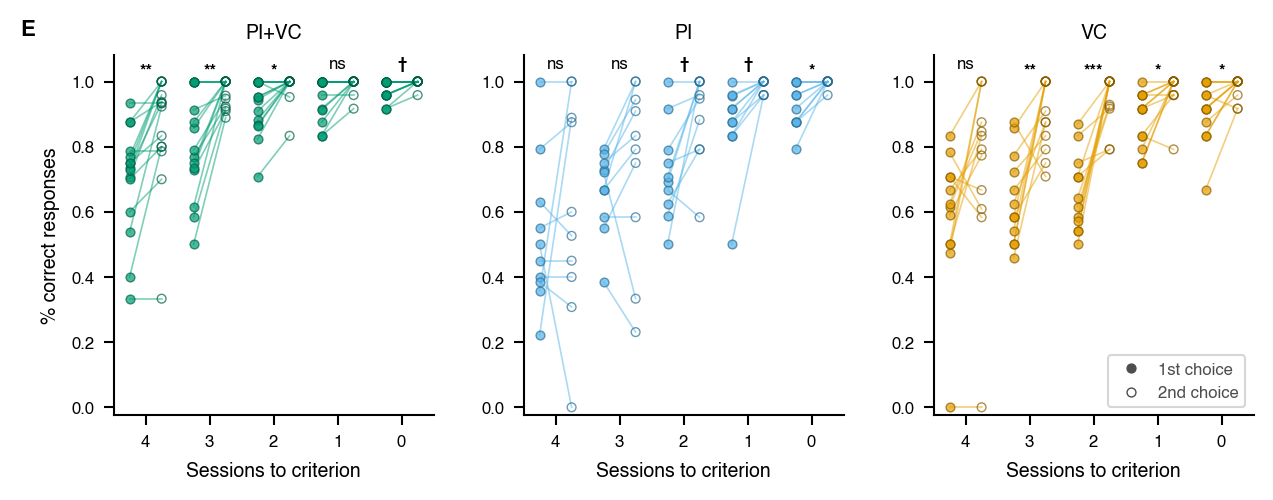

In [25]:
# Panel 2E — choice point accuracy (function form)
from matplotlib.lines import Line2D

def panel_e(axes_list,
            # Scatter / pair-line geometry
            scatter_s=STYLE_CFG['scatter_s'], scatter_alpha=0.7,
            marker_edge_lw=STYLE_CFG['marker_edge_lw_e'],
            pair_line_lw=STYLE_CFG['pair_line_lw'],
            pair_line_alpha=0.5, cp_spread=0.5,
            # Axes
            xlim=(4.5, -0.5), xticks=None, xticklabels=None,
            xlabel='Sessions to criterion',
            ylim=(-0.025, 1.08), yticks=None, ylabel='% correct responses',
            ytick_fmt='{:.1f}',  # tick-label format string; None = matplotlib default
            show_titles=True,
            # Annotation (significance stars / ns / cross)
            star_y=1.01, ns_y_nudge=0.02, cross_y_nudge=0.02,
            star_fontsize=STYLE_CFG['star_fontsize'],
            ns_fontsize=STYLE_CFG['ns_fontsize'],
            # Legend (drawn on the last axes only)
            show_legend=True, legend_loc='lower right',
            legend_fontsize=None, legend_handletextpad=0.6,
            legend_borderpad=0.4, legend_bbox_to_anchor=None,
            legend_top_y=None, legend_x=None):
    """Panel 2E: 1st vs 2nd choice accuracy. axes_list = list of 3 axes."""
    rng = np.random.default_rng(42)
    wide = (
        long.assign(session_to_crit=lambda d: 5 - d['session_number'])
            .pivot_table(index=['group','subject_id','session_to_crit'],
                         columns='choice_point', values='pct_correct', observed=True)
            .reset_index().rename_axis(columns=None)
    )
    cp_offsets = {'1st': +cp_spread / 2, '2nd': -cp_spread / 2}

    if xticks is None:
        xticks = [4, 3, 2, 1, 0]
    if xticklabels is None:
        xticklabels = [str(x) for x in xticks]
    if yticks is None:
        yticks = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

    for ax, g in zip(axes_list, GROUP_ORDER):
        st = STYLE[g]
        d = wide[wide['group'] == g]
        jitter = rng.uniform(0, 0, size=len(d))
        x1 = d['session_to_crit'].values + cp_offsets['1st'] + jitter
        x2 = d['session_to_crit'].values + cp_offsets['2nd'] + jitter
        y1, y2 = d['1st'].values, d['2nd'].values

        for xa, xb, ya, yb in zip(x1, x2, y1, y2):
            ax.plot([xa, xb], [ya, yb], color=st['base'], linewidth=pair_line_lw,
                    alpha=pair_line_alpha, zorder=2)
        ax.scatter(x1, y1, s=scatter_s, facecolor=st['base'], edgecolor=st['edge'],
                   linewidth=marker_edge_lw, alpha=scatter_alpha, zorder=3)
        ax.scatter(x2, y2, s=scatter_s, facecolor='none', edgecolor=st['edge'],
                   linewidth=marker_edge_lw, alpha=scatter_alpha, zorder=3)

        for sn in range(1, 6):
            stc = 5 - sn
            p = posthoc_results.get((g, sn))
            if p is not None:
                label = sig_stars(p)
                is_ns = label == 'ns'
                is_cross = label == '\u2020'
                fs = ns_fontsize if is_ns else star_fontsize
                fw = 'normal' if is_ns else 'bold'
                y_pos = star_y + (ns_y_nudge if is_ns else cross_y_nudge if is_cross else 0)
                ax.text(stc, y_pos, label, ha='center', va='bottom', fontsize=fs,
                        fontweight=fw, clip_on=False)

        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        ax.set_xlim(*xlim)
        ax.set_xlabel(xlabel)
        ax.set_ylim(*ylim)
        ax.set_yticks(yticks)
        if ytick_fmt is not None:
            ax.set_yticklabels([ytick_fmt.format(y) for y in yticks])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if show_titles:
            ax.set_title(g)

    axes_list[0].set_ylabel(ylabel)

    if show_legend:
        handles = [
            Line2D([], [], linestyle='', marker='o', markersize=STYLE_CFG['marker_size'],
                   markerfacecolor=STYLE_CFG['legend_content_color'], markeredgecolor=STYLE_CFG['legend_content_color'],
                   markeredgewidth=marker_edge_lw, label='1st choice'),
            Line2D([], [], linestyle='', marker='o', markersize=STYLE_CFG['marker_size'],
                   markerfacecolor='none', markeredgecolor=STYLE_CFG['legend_content_color'],
                   markeredgewidth=marker_edge_lw, label='2nd choice'),
        ]
        # Shorthand knobs: legend_x / legend_top_y derive bbox_to_anchor.
        # legend_loc determines which corner is anchored:
        #   left/right/center half → x corner;  upper/lower/center half → y corner.
        # legend_top_y forces 'upper *' (anchors the legend's top edge).
        # An explicit legend_bbox_to_anchor wins over both.
        eff_loc, eff_bbox = legend_loc, legend_bbox_to_anchor
        if eff_bbox is None and (legend_top_y is not None or legend_x is not None):
            ll = legend_loc.lower()
            if 'right' in ll:
                ax_default, h = 1.0, 'right'
            elif 'left' in ll:
                ax_default, h = 0.0, 'left'
            else:
                ax_default, h = 0.5, 'center'
            if legend_top_y is not None:
                v, ay_default = 'upper', legend_top_y
            elif 'upper' in ll:
                v, ay_default = 'upper', 1.0
            elif 'lower' in ll:
                v, ay_default = 'lower', 0.0
            else:
                v, ay_default = 'center', 0.5
            bx = legend_x if legend_x is not None else ax_default
            eff_loc = f'{v} {h}' if not (v == 'center' and h == 'center') else 'center'
            eff_bbox = (bx, ay_default)
        leg_kwargs = dict(loc=eff_loc, frameon=True,
                          handletextpad=legend_handletextpad,
                          borderpad=legend_borderpad)
        if legend_fontsize is not None:
            leg_kwargs['fontsize'] = legend_fontsize
        if eff_bbox is not None:
            leg_kwargs['bbox_to_anchor'] = eff_bbox
        leg = axes_list[-1].legend(handles=handles, **leg_kwargs)
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

# Standalone preview
_fig = plt.figure(figsize=(6.6, 2.5))
_axes = [_fig.add_axes([(0.6 + i * 2.05) / 6.6, 0.5 / 2.5, 1.6 / 6.6, 1.8 / 2.5])
         for i in range(3)]
panel_e(_axes)
_fig.text(0.02, 0.96, 'E', fontsize=8, fontweight='bold')
plt.show()


## Panel 2F — trained 2nd response: goal-side vs non-goal-side

Bar chart showing the percentage of **trained** 2nd responses, split by whether the rat made its 2nd turn at the goal-side or non-goal-side perimeter intersection. The trained response (`coord_turn_2 == correct_route[1]`) earns reward only on the goal side; performing it on the non-goal side is habitual (it leads away from reward). Two bars per group: unfilled = goal-side, filled = non-goal-side. Uses coordinate-trace columns `coord_turn_2` (the 2nd turn) and `turn_2_goal_side` (which side it occurred on).

**Session/trial exclusions:**
- Last 5 acquisition sessions per rat (backward from criterion)
- First 8 trials of each session excluded (all groups; matches Fig 2E)
- Exclude sessions with fewer than 3 incorrect 1st choices (too few non-goal trials for a stable estimate)
- Exclude sessions with less than 70% accuracy at the 1st or 2nd choice on the goal side

In [26]:
# Reload trials to pick up stage3d columns
trials = pd.read_parquet(DATA / 'trials.parquet')

# Panel 2F data — per-rat goal-side vs non-goal-side 'trained' 2nd choice
# 'Trained' response = correct_route[1] on BOTH sides (habitual measure)

# Start from acquisition trials with coord turn data
acq_session_ids = set(acq_sessions['session_id'])
acq_f = trials[
    trials['session_id'].isin(acq_session_ids)
    & trials['coord_turn_2'].notna()
    & trials['turn_2_goal_side'].notna()
].copy()

# Merge session rank and subject_id from acq_sessions
acq_f = acq_f.merge(
    acq_sessions[['session_id', 'session_rank_desc', 'subject_id']],
    on='session_id', how='inner'
)
acq_f['group'] = acq_f['subject_id'].map(subj_to_group)

# Filter to last 5 sessions, eligible rats (>=5 sessions)
n_per_rat = acq_sessions.groupby('subject_id', observed=True).size()
eligible = n_per_rat[n_per_rat >= 5].index
acq_f = acq_f[
    acq_f['subject_id'].isin(eligible)
    & (acq_f['session_rank_desc'] <= 4)
].copy()

# Exclude the first 8 trials (first block) of each session for ALL groups —
# applied symmetrically so the between-group comparison is unbiased
# (the first block precedes spatial reorientation, which most affects PI rats)
early = acq_f['trial_number'] <= 8
acq_f = acq_f[~early].copy()

# 'Trained' response = correct_route[1] — same L/R on both sides
cr1 = acq_f['correct_route'].astype('string').str[1]
cr0 = acq_f['correct_route'].astype('string').str[0]
acq_f['trained_2nd'] = (acq_f['coord_turn_2'] == cr1)
acq_f['c1_correct'] = (acq_f['coord_turn_1'] == cr0)

# Per-rat, per-session aggregation
def session_stats(g):
    gs = g[g['turn_2_goal_side'] == True]
    ngs = g[g['turn_2_goal_side'] == False]
    return pd.Series({
        'goal_2nd_acc': gs['trained_2nd'].mean() if len(gs) else np.nan,
        'nongoal_2nd_acc': ngs['trained_2nd'].mean() if len(ngs) else np.nan,
        'n_wrong_first': (~g['c1_correct']).sum(),
        'goal_1st_acc': gs['c1_correct'].mean() if len(gs) else np.nan,
        'goal_2nd_trained': gs['trained_2nd'].mean() if len(gs) else np.nan,
        'n_total': len(g),
    })

per_sess = (
    acq_f.groupby(['group', 'subject_id', 'session_id'], observed=True)
    .apply(session_stats)
    .reset_index()
)

# Session exclusions
n_before = len(per_sess)
per_sess = per_sess[
    (per_sess['n_wrong_first'] >= 3)
    & (per_sess['goal_1st_acc'] >= 0.70)
    & (per_sess['goal_2nd_trained'] >= 0.70)
]
n_after = len(per_sess)
print(f'Sessions before exclusions: {n_before}, after: {n_after} '
      f'({n_before - n_after} excluded)')

# Collapse to per-rat means
per_rat = (
    per_sess.groupby(['group', 'subject_id'], observed=True)
    .agg(goal_acc=('goal_2nd_acc', 'mean'), nongoal_acc=('nongoal_2nd_acc', 'mean'))
    .reset_index()
)

n_per_group_2f = per_rat.groupby('group', observed=True)['subject_id'].nunique().reindex(GROUP_ORDER)
print(f'Rats with data after exclusions: {len(per_rat)} '
      f"({', '.join(f'{g} n = {int(n)}' for g, n in n_per_group_2f.items())})")
print()
print('Per-group mean % trained 2nd response:')
print(per_rat.groupby('group', observed=True)[['goal_acc', 'nongoal_acc']].mean().loc[GROUP_ORDER].round(3))


Sessions before exclusions: 185, after: 76 (109 excluded)
Rats with data after exclusions: 32 (PI+VC n = 11, PI n = 9, VC n = 12)

Per-group mean % trained 2nd response:
       goal_acc  nongoal_acc
group                       
PI+VC     0.954        0.838
PI        0.946        0.596
VC        0.937        0.871


In [27]:
# Panel 2F — 2x3 mixed ANOVA (side x group)
import pingouin as pg

long_f = per_rat.melt(
    id_vars=['group', 'subject_id'],
    value_vars=['goal_acc', 'nongoal_acc'],
    var_name='side', value_name='accuracy',
)
long_f['side'] = long_f['side'].map({'goal_acc': 'goal', 'nongoal_acc': 'nongoal'})

# Drop rats with NaN accuracy (missing non-goal data after exclusions)
long_f = long_f.dropna(subset=['accuracy'])
# Keep only rats that have both sides
both_sides = long_f.groupby('subject_id').filter(lambda g: len(g) == 2)

# afex::aov_ez (Type 3). With a two-level within factor there is no sphericity
# question (no Mauchly test), but the side main effect differs from pingouin's
# weighted-means version (43.15 vs 37.00) because group sizes are unequal; the
# group and interaction F are identical. The manuscript cites the afex values.
aov_f = mixed_anova_afex(both_sides, 'accuracy', within='side', label='2F side x group')
print()
print('Original draft (SPSS): F(1,37) = 51.9, p < .001 for main effect of side')


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== 2F side x group: 2 x 3 mixed ANOVA (side within × group between), afex::aov_ez Type 3; n = 32 ===
Mauchly's test: not applicable (2 within levels); no sphericity correction
     Source     F df (unc)   p (unc) df (GG) p (GG)   np2
      group  7.56    2, 29  0.002277       -      - 0.343
       side 43.15    1, 29  3.39e-07       -      - 0.598
Interaction  9.87    2, 29 0.0005386       -      - 0.405
Reported (GG_RULE = 'mauchly' -> uncorrected df): group F(2, 29) = 7.56, p = .002; side F(1, 29) = 43.15, p < .001; side × group F(2, 29) = 9.87, p < .001

Original draft (SPSS): F(1,37) = 51.9, p < .001 for main effect of side


In [28]:
# Panel 2F — post-hoc: per-group paired t-tests (goal vs nongoal), Bonferroni-corrected
# Plus Bayes Factor for groups where frequentist test is non-significant
from scipy import stats
import pingouin as pg

posthoc_2f = {}
bf_2f = {}
for g in GROUP_ORDER:
    d = per_rat[(per_rat['group'] == g)].dropna(subset=['goal_acc', 'nongoal_acc'])
    if len(d) < 3:
        continue
    t_stat, p_val = stats.ttest_rel(d['goal_acc'], d['nongoal_acc'])
    posthoc_2f[g] = p_val
    # Bayes Factor: BF10 > 3 = evidence for difference, BF10 < 1/3 = evidence for null
    bf10 = pg.bayesfactor_ttest(t_stat, len(d), paired=True)
    bf_2f[g] = bf10

# Bonferroni correction (3 comparisons)
n_tests = len(posthoc_2f)
posthoc_2f_corr = {g: min(p * n_tests, 1.0) for g, p in posthoc_2f.items()}

def sig_stars_2f(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def bf_interpretation(bf10):
    bf01 = 1 / bf10
    if bf01 > 10:  return f'BF01={bf01:.1f} (strong evidence for null)'
    if bf01 > 3:   return f'BF01={bf01:.1f} (moderate evidence for null)'
    if bf10 > 10:  return f'BF10={bf10:.1f} (strong evidence for difference)'
    if bf10 > 3:   return f'BF10={bf10:.1f} (moderate evidence for difference)'
    return f'BF10={bf10:.1f} (inconclusive)'

print('Post-hoc paired t-tests (goal vs nongoal), Bonferroni-corrected:')
print()
for g in GROUP_ORDER:
    if g in posthoc_2f:
        p_raw = posthoc_2f[g]
        p_corr = posthoc_2f_corr[g]
        bf10 = bf_2f[g]
        print(f'  {g:8s}: p_raw={p_raw:.4f}, p_corr={p_corr:.4f} {sig_stars_2f(p_corr)}  |  {bf_interpretation(bf10)}')

# Non-goal-side trained responses vs chance (50%): one-sample t per group (two-tailed), with
# Wilcoxon and dz. (Manuscript: PI+VC 83.8% and VC 87.1% both p < .001; PI 59.6%, p = .052.)
print('\nNon-goal-side trained responses vs chance (50%), one-sample t per group:')
chance_2f = {}
for g in GROUP_ORDER:
    v = per_rat.loc[per_rat['group'] == g, 'nongoal_acc'].dropna().to_numpy()
    if len(v) < 3:
        continue
    t_c, p_c = stats.ttest_1samp(v, 0.5)
    w_c = stats.wilcoxon(v - 0.5).pvalue
    dz_c = (v.mean() - 0.5) / v.std(ddof=1)
    chance_2f[g] = p_c
    print(f'  {g:8s}: n={len(v):2d}  mean={v.mean()*100:5.1f}%  t({len(v)-1})={t_c:.2f}, p={p_c:.4f} {sig_stars_2f(p_c)}'
          f'  |  Wilcoxon p={w_c:.4f}, dz={dz_c:.2f}')


Post-hoc paired t-tests (goal vs nongoal), Bonferroni-corrected:

  PI+VC   : p_raw=0.0820, p_corr=0.2460 ns  |  BF10=1.2 (inconclusive)
  PI      : p_raw=0.0000, p_corr=0.0001 ***  |  BF10=780.2 (strong evidence for difference)
  VC      : p_raw=0.0747, p_corr=0.2240 ns  |  BF10=1.2 (inconclusive)

Non-goal-side trained responses vs chance (50%), one-sample t per group:
  PI+VC   : n=11  mean= 83.8%  t(10)=6.95, p=0.0000 ***  |  Wilcoxon p=0.0010, dz=2.10
  PI      : n= 9  mean= 59.6%  t(8)=2.28, p=0.0524 ns  |  Wilcoxon p=0.0703, dz=0.76
  VC      : n=12  mean= 87.1%  t(11)=10.24, p=0.0000 ***  |  Wilcoxon p=0.0005, dz=2.96


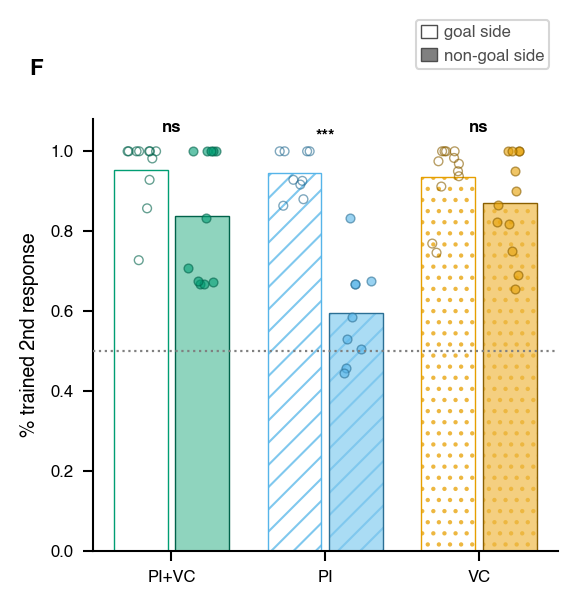

In [29]:
# Panel 2F — goal-side vs non-goal-side (function form)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

def panel_f(ax, bar_width=0.35, bar_gap=0.05, scatter_s=STYLE_CFG['scatter_s'], scatter_alpha=0.6,
            star_y=1.02, ns_y=1.04,
            star_fontsize=STYLE_CFG['star_fontsize'],
            bar_edge_lw=STYLE_CFG['bar_edge_lw'],
            scatter_edge_lw=STYLE_CFG['scatter_edge_lw_f'],
            axhline_lw=STYLE_CFG['axhline_lw'],
            legend_frame_lw=STYLE_CFG['legend_frame_lw'],
            chance_line=True, show_legend=True,
            # Axes
            xticks=None, xticklabels=None, xlabel=None,
            ylim=(0.0, 1.08), yticks=None, ylabel='% trained 2nd response',
            # Legend
            legend_loc='upper right', legend_top_y=None,
            legend_bbox=(1, 1.25), legend_fontsize=6, legend_markerscale=0.3,
            legend_handlelength=1.0, legend_handleheight=0.8,
            legend_handletextpad=0.4, legend_borderpad=0.3):
    """Panel 2F: goal-side vs non-goal-side trained 2nd response."""
    rng = np.random.default_rng(42)
    x_positions = np.arange(len(GROUP_ORDER))

    for i, g in enumerate(GROUP_ORDER):
        st = STYLE[g]
        d = per_rat[per_rat['group'] == g]
        goal_mean = d['goal_acc'].mean()
        nongoal_mean = d['nongoal_acc'].mean()
        x_goal = x_positions[i] - (bar_width / 2 + bar_gap / 2)
        x_nongoal = x_positions[i] + (bar_width / 2 + bar_gap / 2)

        # Goal-side: fill, hatch, border
        ax.bar(x_goal, goal_mean, width=bar_width,
               facecolor='white', edgecolor='none', linewidth=0, zorder=2)
        if st['hatch']:
            ax.bar(x_goal, goal_mean, width=bar_width,
                   facecolor='none', edgecolor=st['hatch_color'],
                   hatch=st['hatch'], linewidth=0, zorder=2.1)
        ax.bar(x_goal, goal_mean, width=bar_width,
               facecolor='none', edgecolor=st['base'], linewidth=bar_edge_lw, zorder=2.2)

        # Non-goal-side: fill, hatch, border
        ax.bar(x_nongoal, nongoal_mean, width=bar_width,
               facecolor=st['fill'], edgecolor='none', linewidth=0, zorder=2)
        if st['hatch']:
            ax.bar(x_nongoal, nongoal_mean, width=bar_width,
                   facecolor='none', edgecolor=st['hatch_color'],
                   hatch=st['hatch'], linewidth=0, zorder=2.1)
        ax.bar(x_nongoal, nongoal_mean, width=bar_width,
               facecolor='none', edgecolor=st['edge'], linewidth=bar_edge_lw, zorder=2.2)

        # Dots
        jg = rng.uniform(-bar_width * 0.3, bar_width * 0.3, size=len(d))
        jn = rng.uniform(-bar_width * 0.3, bar_width * 0.3, size=len(d))
        ax.scatter(x_goal + jg, d['goal_acc'].values, s=scatter_s,
                   facecolor='none', edgecolor=st['edge'], linewidth=scatter_edge_lw,
                   alpha=scatter_alpha, zorder=3)
        ax.scatter(x_nongoal + jn, d['nongoal_acc'].dropna().values, s=scatter_s,
                   facecolor=st['base'], edgecolor=st['edge'], linewidth=scatter_edge_lw,
                   alpha=scatter_alpha, zorder=3)

    if chance_line:
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=axhline_lw, zorder=4)

    # Stars
    for i, g in enumerate(GROUP_ORDER):
        p = posthoc_2f_corr.get(g)
        if p is not None:
            label = sig_stars_2f(p)
            y_pos = ns_y if label == 'ns' else star_y
            ax.text(x_positions[i], y_pos, label, ha='center', va='bottom',
                    fontsize=star_fontsize, fontweight='bold', clip_on=False)

    ax.set_xticks(xticks if xticks is not None else x_positions)
    ax.set_xticklabels(xticklabels if xticklabels is not None else GROUP_ORDER)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_ylim(*ylim)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        handles = [
            Patch(facecolor='white', edgecolor='0.3', linewidth=legend_frame_lw, label='goal side'),
            Patch(facecolor='0.5', edgecolor='0.3', linewidth=legend_frame_lw, label='non-goal side'),
        ]
        # legend_top_y is a shorthand: pin legend's top edge at axes-y = legend_top_y,
        # picking anchor-x from legend_bbox[0]. Overrides legend_bbox[1] when set.
        bbox = (legend_bbox[0], legend_top_y) if legend_top_y is not None else legend_bbox
        leg = ax.legend(handles=handles, loc=legend_loc, bbox_to_anchor=bbox,
                        frameon=True, fontsize=legend_fontsize, markerscale=legend_markerscale,
                        handlelength=legend_handlelength, handleheight=legend_handleheight,
                        handletextpad=legend_handletextpad, borderpad=legend_borderpad)
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

# Standalone preview
_fig, _ax = plt.subplots(figsize=(3.0, 2.8))
panel_f(_ax)
_fig.text(0.02, 0.96, 'F', fontsize=8, fontweight='bold')
plt.show()


## Panel 2G — PI+VC (fixed 1st) vs PI+VC (fixed 2nd)

**Question.** Is the 2nd-choice-point advantage in Panel 2E due to the 2nd point's *proximity to the goal*, or to the *stability of the required response*? Two PI+VC cohorts are compared:

- **PI+VC (fixed 2nd)** — the main n = 17 group above: the correct 2nd turn is constant across trials, the 1st varies with start arm.
- **PI+VC (fixed 1st, "F1")** — a separate cohort (n = 6, `subjects.yaml` → `figure2.PI+VC_f1`; excludes CM059): the reverse, correct 1st turn constant, 2nd varies.

If proximity drove the effect, both groups would learn the 2nd point faster. If response stability drove it, each group learns *its own* fixed choice point faster — a crossover.

**Sub-panels** (schematic G1 from `figures/images/fig_2g.svg`, drawn with the Panel B/C/D functions so styling is identical):
- **G2** trials to criterion (as B);
- **G3** % correct per session aligned to criterion (as C), displayed for sessions-to-criterion 0–11 (rat 123's earliest 10 of 22 sessions fall off-axis; median line drawn where ≥ 2 rats remain);
- **G4** % correct across the four 8-trial blocks of the criterion session (as D: mean ± SEM);
- **G5** choice-point **difference score** = 2nd − 1st choice accuracy per rat × session (positive = 2nd-choice advantage), one axes instead of separate 1st-choice and 2nd-choice panels. The crossover shows as the groups sitting on opposite sides of zero.

**Measure and filters (as Panel 2E, except no first-block drop).** 1st correct = `actual_route[0] == correct_route[0]`; 2nd correct = `actual_route[1] == correct_route[1]` (trained response, all trials). Last 5 acquisition sessions, **all trials of each session** (the first-8-trial drop used in Panel 2E is not applied here: it exists to equate the within-session warm-up across the three cue groups, which is moot for this PI+VC-vs-F1 comparison, and it left some early F1 sessions with only 2–6 trials), rats with ≥ 5 acquisition sessions and a complete 5-session × 2-choice grid → fixed-1st **n = 5** (rat 127 has only 3 sessions), fixed-2nd **n = 15**.


In [30]:
# Panel 2G data — PI+VC (fixed 1st) vs PI+VC (fixed 2nd)
# Reload the parquets: the Fig 2 cohort filter (preamble) drops the fixed-1st rats and the
# Panel F cell rebinds `trials` unmerged. Everything in the Panel G section is suffixed `_g`.
f1_ids_g = cohort['PI+VC_f1']   # the F1 group, listed under figure2 in subjects.yaml
subjects_g = pd.read_parquet(DATA / 'subjects.parquet')
sessions_g = pd.read_parquet(DATA / 'sessions.parquet')
trials_g   = pd.read_parquet(DATA / 'trials.parquet')

f2_ids_g = subjects_g.loc[subjects_g['training_group'] == 'PI+VC', 'subject_id'].tolist()
assert set(f2_ids_g) == set(cohort['PI+VC']), 'fixed-2nd cohort must equal the Fig 2 PI+VC group'
subj_to_group_g = {i: 'PI+VC_f1' for i in f1_ids_g}
subj_to_group_g.update({i: 'PI+VC' for i in f2_ids_g})
cohort_ids_g = list(subj_to_group_g)

subjects_g = subjects_g[subjects_g['subject_id'].isin(cohort_ids_g)].copy()
subjects_g['group'] = subjects_g['subject_id'].map(subj_to_group_g)
sessions_g = sessions_g[sessions_g['subject_id'].isin(cohort_ids_g)].copy()
sessions_g['group'] = sessions_g['subject_id'].map(subj_to_group_g)
trials_g = trials_g.merge(sessions_g[['session_id', 'subject_id', 'group', 'session_experiment_phase']],
                          on='session_id', how='inner')

acq_sessions_g = (sessions_g[sessions_g['session_experiment_phase'] == 'Acquisition']
                  .sort_values(['subject_id', 'session_id']).copy())
acq_sessions_g['session_rank_desc'] = (acq_sessions_g.groupby('subject_id', observed=True)
                                       .cumcount(ascending=False))

# --- G2: trials to criterion (same definition as Panel B) ---
tta_g = (acq_sessions_g.groupby(['group', 'subject_id'], observed=True)['total_trials'].sum()
         .reset_index(name='trials_to_criterion')
         .merge(subjects_g[['subject_id', 'sex', 'approach_to_goal']], on='subject_id'))

# --- G3: % correct per session aligned to criterion (same definition as Panel C) ---
G_MAX_SESSIONS = 11   # display cap: sessions-to-criterion 0..11 (rat 123 has 22 acquisition sessions)
acq_trials_g = trials_g[trials_g['session_experiment_phase'] == 'Acquisition'].copy()
acq_trials_g['correct'] = (acq_trials_g['errors'] == 0).astype(float)
pct_by_session_g = (acq_trials_g.groupby('session_id', observed=True)['correct'].mean()
                    .reset_index(name='pct_correct'))
sess_acc_g = (acq_sessions_g[['session_id', 'subject_id', 'group', 'session_rank_desc']]
              .merge(pct_by_session_g, on='session_id'))
n_off_axis_g = int((sess_acc_g['session_rank_desc'] > G_MAX_SESSIONS).sum())
sess_acc_g = sess_acc_g[sess_acc_g['session_rank_desc'] <= G_MAX_SESSIONS].copy()

# --- G4: four 8-trial blocks on the criterion session (same definition as Panel D) ---
final_ids_g = sess_acc_g.loc[sess_acc_g['session_rank_desc'] == 0, ['subject_id', 'session_id']]
final_trials_g = acq_trials_g.merge(final_ids_g, on=['subject_id', 'session_id'], how='inner')
final_trials_g = final_trials_g[final_trials_g['trial_number'].between(1, 32)].copy()
final_trials_g['block'] = ((final_trials_g['trial_number'] - 1) // 8 + 1).astype(int)
block_acc_g = (final_trials_g.groupby(['group', 'subject_id', 'block'], observed=True)['correct']
               .mean().reset_index(name='pct_correct'))

print('Panel G cohort (rats by group x sex):')
print(subjects_g.groupby(['group', 'sex'], observed=True).size().unstack(fill_value=0).reindex(GROUP_ORDER_G))
n_acq_g = acq_sessions_g.groupby('subject_id', observed=True).size()
print('acquisition sessions per fixed-1st rat:', {int(i): int(n_acq_g.get(i, 0)) for i in f1_ids_g})
print(f'G3 display cap: {n_off_axis_g} session(s) beyond sessions-to-criterion {G_MAX_SESSIONS} not shown')
print()
print('Trials to criterion:')
print(tta_g.groupby('group', observed=True)['trials_to_criterion']
      .agg(['mean', 'sem', 'count']).reindex(GROUP_ORDER_G).round(1))


Panel G cohort (rats by group x sex):
sex       F  M
group         
PI+VC_f1  3  3
PI+VC     9  8
acquisition sessions per fixed-1st rat: {123: 22, 124: 8, 126: 5, 127: 3, 129: 7, 130: 11}
G3 display cap: 10 session(s) beyond sessions-to-criterion 11 not shown

Trials to criterion:
           mean   sem  count
group                       
PI+VC_f1  185.7  37.3      6
PI+VC     159.4  10.3     17


In [31]:
# Panel 2G2 — trials to criterion: fixed 1st vs fixed 2nd
# Small, unequal n (6 vs 17): Welch t plus Mann-Whitney and Hedges g.
from scipy import stats
import pingouin as pg

tta_f1 = tta_g.loc[tta_g['group'] == 'PI+VC_f1', 'trials_to_criterion'].to_numpy()
tta_f2 = tta_g.loc[tta_g['group'] == 'PI+VC', 'trials_to_criterion'].to_numpy()
t_tta_g, p_tta_g = stats.ttest_ind(tta_f1, tta_f2, equal_var=False)
u_tta_g, p_u_tta_g = stats.mannwhitneyu(tta_f1, tta_f2)
hedges_tta_g = pg.compute_effsize(tta_f1, tta_f2, eftype='hedges')
print(f'fixed-1st n={len(tta_f1)} mean={tta_f1.mean():.1f} | fixed-2nd n={len(tta_f2)} mean={tta_f2.mean():.1f}')
print(f'Welch t={t_tta_g:.2f}, p={p_tta_g:.3f} | Mann-Whitney U={u_tta_g:.0f}, p={p_u_tta_g:.3f} | Hedges g={hedges_tta_g:+.2f}')


fixed-1st n=6 mean=185.7 | fixed-2nd n=17 mean=159.4
Welch t=0.68, p=0.524 | Mann-Whitney U=60, p=0.528 | Hedges g=+0.44


### Panel 2G5 data — choice-point accuracy and difference score

Per rat × session (last 5 sessions, all trials, no first-block drop), 1st- and 2nd-choice accuracy scored as in Panel 2E (`_char_at` helper from the 2E data cell), then **diff = 2nd − 1st**. One value per rat per session → a 2 (group, between) × 5 (session, within) design with no within-cell aggregation left to do.


In [32]:
# Panel 2G5 data — per-rat x session 1st/2nd choice accuracy and diff = 2nd - 1st
# Measure as the Panel 2E data cell; same session filters, but ALL trials of each
# session are kept (no first-8-trial drop: that equates warm-up across cue groups,
# which is irrelevant for PI+VC vs F1, and it starved short early F1 sessions).
ct_g = trials_g[trials_g['session_experiment_phase'] == 'Acquisition'].copy()
ct_g['first_ok'] = (ct_g['actual_route'].apply(lambda r: _char_at(r, 0))
                    == ct_g['correct_route'].apply(lambda r: _char_at(r, 0))).astype(int)
_ar1_g = ct_g['actual_route'].apply(lambda r: _char_at(r, 1))
_cr1_g = ct_g['correct_route'].apply(lambda r: _char_at(r, 1))
ct_g['second_ok'] = np.where(_ar1_g.isna() | _cr1_g.isna(), np.nan, (_ar1_g == _cr1_g).astype(float))

n_per_rat_g = acq_sessions_g.groupby('subject_id', observed=True).size()
eligible_g = n_per_rat_g[n_per_rat_g >= 5].index
ct_g = ct_g.merge(acq_sessions_g[['session_id', 'session_rank_desc']], on='session_id', how='inner')
last5_g = ct_g[ct_g['subject_id'].isin(eligible_g)
               & (ct_g['session_rank_desc'] <= 4)].copy()   # all trials kept
last5_g['session_number'] = 5 - last5_g['session_rank_desc'].astype(int)

per_g = (last5_g.groupby(['group', 'subject_id', 'session_number'], observed=True)
         .agg(first=('first_ok', 'mean'), second=('second_ok', 'mean'),
              n_trials=('first_ok', 'size')).reset_index())
# keep rats with a complete 5-session x 2-choice grid
_cnt_g = per_g.dropna(subset=['first', 'second']).groupby('subject_id').size()
per_g = per_g[per_g['subject_id'].isin(_cnt_g[_cnt_g == 5].index)].copy()
per_g['diff'] = per_g['second'] - per_g['first']            # + = 2nd-choice advantage
per_g['session_to_crit'] = 5 - per_g['session_number']

print('Choice-point cohort (>= 5 sessions, complete grid):')
print(per_g.groupby('group', observed=True)['subject_id'].nunique().reindex(GROUP_ORDER_G).to_string())
# Sex of the rats retained by the >= 5-session / complete-grid filter (manuscript: F1 n = 5, 2 M / 3 F)
_kept_g = subjects_g[subjects_g['subject_id'].isin(per_g['subject_id'].unique())]
print('by sex:')
print(_kept_g.groupby(['group', 'sex'], observed=True).size().unstack(fill_value=0)
      .reindex(GROUP_ORDER_G).to_string())
print()
print('Mean 1st / 2nd accuracy and diff (2nd - 1st) by group:')
print(per_g.groupby('group', observed=True)[['first', 'second', 'diff']].mean().reindex(GROUP_ORDER_G).round(3))
print()
print('Trials per rat x session (min / median / max):')
print(per_g.groupby('group', observed=True)['n_trials'].agg(['min', 'median', 'max']).reindex(GROUP_ORDER_G))
print()
print('Mean diff by group x sessions-to-criterion:')
print(per_g.pivot_table(index='group', columns='session_to_crit', values='diff', observed=True)
      .reindex(GROUP_ORDER_G).round(3))


Choice-point cohort (>= 5 sessions, complete grid):
group
PI+VC_f1     5
PI+VC       15
by sex:
sex       F  M
group         
PI+VC_f1  3  2
PI+VC     7  8

Mean 1st / 2nd accuracy and diff (2nd - 1st) by group:
          first  second   diff
group                         
PI+VC_f1  0.880   0.753 -0.127
PI+VC     0.816   0.938  0.122

Trials per rat x session (min / median / max):
          min  median  max
group                     
PI+VC_f1   10    32.0   32
PI+VC      11    29.0   32

Mean diff by group x sessions-to-criterion:
session_to_crit      0      1      2      3      4
group                                             
PI+VC_f1        -0.062 -0.138 -0.061 -0.242 -0.133
PI+VC            0.035  0.081  0.111  0.188  0.194


### Panel 2G5 — 2 × 5 mixed ANOVA on the difference score (afex via rpy2)

Group (fixed 1st / fixed 2nd) between, session (1–5) within, Greenhouse-Geisser corrected; `intercept = TRUE` because the intercept is the overall 1st-vs-2nd effect. The key term is **group** (the crossover: does the sign of the choice-point advantage differ between cohorts?); **group × session** tests whether the crossover changes over sessions.

These are the choice-point terms of the full 2 × 5 × 2 design of the former `supp_figure2` notebook (intercept ↔ choice point; group ↔ group × choice; session ↔ choice × session; group × session ↔ three-way). With the first-8-trial drop, that notebook gave group F(1, 18) = 18.29, p = .0005 and group × session F(2.13, 38.4) = 3.73, p = .031; the values here use all trials, so they differ slightly.

Follow-ups: per group, a one-sample t-test (and Wilcoxon, given the fixed-1st n = 5) of the mean difference score vs 0; per session, Welch t-tests between groups, Holm-corrected across the 5 sessions. The per-session Holm p-values drive the significance marks above each session in G5 (same star / † / ns convention as Panel E).


In [33]:
# Panel 2G5 — 2 x 5 mixed ANOVA on diff = 2nd - 1st via R's afex::aov_ez (Greenhouse-Geisser)
from rpy2.robjects import r, pandas2ri, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
from rpy2.robjects.packages import importr

importr('afex')

with localconverter(default_converter + pandas2ri.converter):
    r_df_g = per_g[['group', 'subject_id', 'session_number', 'diff']].copy()
    r_df_g['subject_id']     = r_df_g['subject_id'].astype(str)
    r_df_g['session_number'] = r_df_g['session_number'].astype(str)
    globalenv['df_g'] = r_df_g   # auto-converts to R data.frame

    r_code_g = """
    df_g$subject_id     <- factor(df_g$subject_id)
    df_g$session_number <- factor(df_g$session_number, levels = as.character(1:5))
    df_g$group          <- factor(df_g$group, levels = c('PI+VC_f1','PI+VC'))

    fit_g <- afex::aov_ez(
      id = 'subject_id', dv = 'diff',
      within = 'session_number',
      between = 'group',
      data = df_g,
      anova_table = list(correction = 'GG', es = 'pes', intercept = TRUE)
    )
    fit_g$anova_table
    """
    aov_g = r(r_code_g)   # pandas DataFrame inside the converter context

print('2 x 5 mixed ANOVA on diff = 2nd - 1st (afex::aov_ez, Greenhouse-Geisser):')
print(aov_g.round(4).to_string())

# Sphericity (afex summary: Mauchly's test and the GG / HF epsilons for the session terms).
# Mauchly rejects, so the GG df in the table above are the reported ones.
print("\nMauchly's test and epsilons (afex summary):")
print('\n'.join(list(r('capture.output(print(summary(fit_g)$sphericity.tests))'))))
print('\n'.join(list(r('capture.output(print(summary(fit_g)$pval.adjustments))'))))
print()
print('Reference (former supp_figure2 notebook, WITH the first-8-trial drop; not expected to match exactly):')
print('  group F(1, 18) = 18.29, p = .0005;  group:session_number F(2.13, 38.4) = 3.73, p = .031')


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


2 x 5 mixed ANOVA on diff = 2nd - 1st (afex::aov_ez, Greenhouse-Geisser):
                      num Df   den Df     MSE        F     pes  Pr(>F)
(Intercept)           1.0000  18.0000  0.0298   0.0179  0.0010  0.8949
group                 1.0000  18.0000  0.0298  38.9969  0.6842  0.0000
session_number        2.5763  46.3737  0.0233   0.8063  0.0429  0.4804
group:session_number  2.5763  46.3737  0.0233   4.2739  0.1919  0.0129

Mauchly's test and epsilons (afex summary):
                     Test statistic   p-value
session_number              0.23483 0.0048516
group:session_number        0.23483 0.0048516
                        GG eps Pr(>F[GG])    HF eps  Pr(>F[HF])
session_number       0.6440793 0.48036722 0.7610055 0.497356171
group:session_number 0.6440793 0.01289038 0.7610055 0.008516053
attr(,"na.action")
(Intercept)       group 
          1           2 
attr(,"class")
[1] "omit"

Reference (former supp_figure2 notebook, WITH the first-8-trial drop; not expected to match exactly)

In [34]:
# Panel 2G5 — follow-ups on the difference score
from scipy import stats
import pingouin as pg

rat_mean_g = per_g.groupby(['group', 'subject_id'], observed=True)['diff'].mean().reset_index()
print('Per-group one-sample tests of mean diff vs 0 (collapsed across sessions):')
for g in GROUP_ORDER_G:
    _v = rat_mean_g.loc[rat_mean_g['group'] == g, 'diff'].to_numpy()
    _t, _p = stats.ttest_1samp(_v, 0)
    _w = stats.wilcoxon(_v)
    _dz = _v.mean() / _v.std(ddof=1)
    print(f"  {GROUP_LABELS_G[g]:6s} n={len(_v)}  mean={_v.mean():+.3f}  t({len(_v)-1})={_t:+.2f}, "
          f"p={_p:.4f} {sig_stars(_p)}  | Wilcoxon p={_w.pvalue:.3f}  | dz={_dz:+.2f}")

# Per session: Welch t between groups on diff, Holm-corrected across the 5 sessions.
# posthoc_g: sessions-to-criterion -> Holm p; drives the marks above each session in G5.
wide_g = per_g.pivot_table(index=['group', 'subject_id'], columns='session_to_crit',
                           values='diff', observed=True)
raw_g = []
for stc in [4, 3, 2, 1, 0]:
    _a = wide_g.loc['PI+VC_f1', stc].to_numpy()
    _b = wide_g.loc['PI+VC', stc].to_numpy()
    _t, _p = stats.ttest_ind(_a, _b, equal_var=False)
    raw_g.append((stc, _t, _p, pg.compute_effsize(_a, _b, eftype='hedges')))
holm_g = pg.multicomp([p for _, _, p, _ in raw_g], method='holm')[1]
posthoc_g = {stc: float(ph) for (stc, _, _, _), ph in zip(raw_g, holm_g)}

print()
print('Per-session Welch t-tests between groups on diff (Holm-corrected across 5 sessions):')
for (stc, _t, _p, _es), ph in zip(raw_g, holm_g):
    print(f"  sessions-to-criterion {stc}: t={_t:+.2f}, p={_p:.4f}, p_holm={ph:.4f} {sig_stars(ph)}  Hedges g={_es:+.2f}")


Per-group one-sample tests of mean diff vs 0 (collapsed across sessions):
  F1     n=5  mean=-0.127  t(4)=-2.03, p=0.1119 ns  | Wilcoxon p=0.188  | dz=-0.91
  PI+VC  n=15  mean=+0.122  t(14)=+10.37, p=0.0000 ***  | Wilcoxon p=0.000  | dz=+2.68

Per-session Welch t-tests between groups on diff (Holm-corrected across 5 sessions):
  sessions-to-criterion 4: t=-2.17, p=0.0873, p_holm=0.0934 †  Hedges g=-1.54
  sessions-to-criterion 3: t=-4.09, p=0.0086, p_holm=0.0431 *  Hedges g=-2.50
  sessions-to-criterion 2: t=-2.84, p=0.0346, p_holm=0.0934 †  Hedges g=-1.75
  sessions-to-criterion 1: t=-3.04, p=0.0311, p_holm=0.0934 †  Hedges g=-2.09
  sessions-to-criterion 0: t=-3.21, p=0.0202, p_holm=0.0807 †  Hedges g=-1.84


### Panel 2G figure

G2–G4 reuse `panel_b` / `panel_c` / `panel_d` with `data=` / `groups=` (so bars, hatches, medians, and legends are drawn by the same code as B–D). G5 is `panel_g_diff`: per-rat difference scores (jittered, group-offset) with the group mean ± SEM, a dotted zero line, and the Holm-corrected between-group mark above each session. X-axis reversed so criterion (0) is on the right, as in C and E.


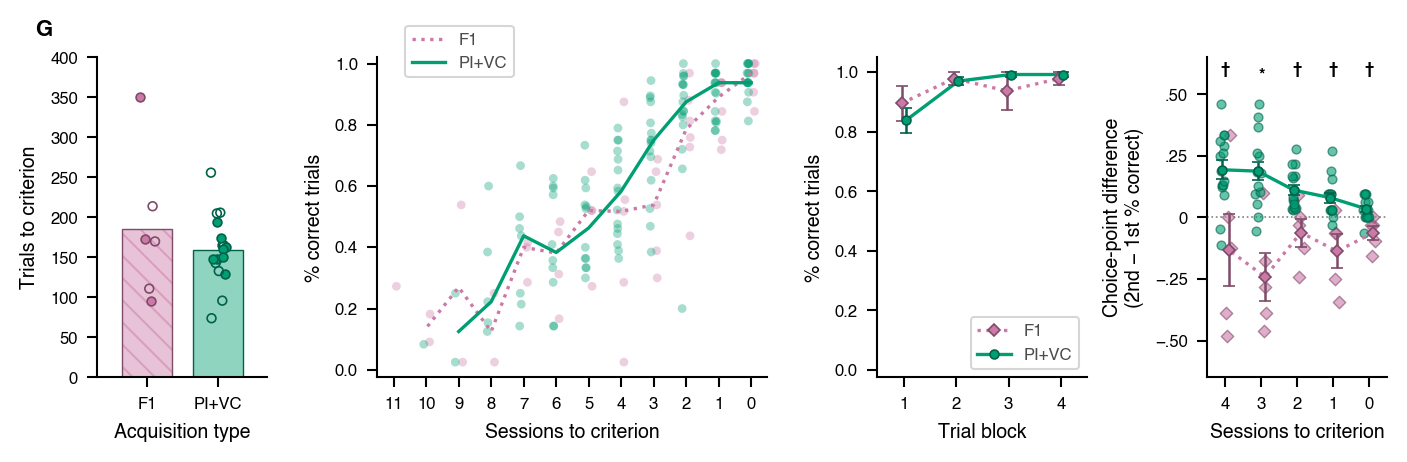

In [35]:
# Panel 2G5 — choice-point difference score (function form) + Panel G preview strip
from matplotlib.lines import Line2D

def fmt_no_lead_zero(y, decimals=2):
    """Tick label without the ones-place zero: -0.25 -> '\u2212.25', 0.5 -> '.50';
    exact zero -> '0'. Honours axes.unicode_minus like matplotlib's default formatter
    (same convention as Fig 3C)."""
    if abs(y) < 1e-9:
        return '0'
    s = f'{abs(y):.{decimals}f}'
    if s.startswith('0.'):
        s = s[1:]
    minus = '\u2212' if plt.rcParams['axes.unicode_minus'] else '-'
    return (minus if y < 0 else '') + s


def panel_g_diff(ax,
                 # Scatter / errorbar geometry
                 scatter_s=STYLE_CFG['scatter_s'], scatter_alpha=0.6,
                 jitter=0.08, group_offset=0.10, line_lw=1.2,
                 marker_size=STYLE_CFG['marker_size'],
                 marker_edge_lw=STYLE_CFG['marker_edge_lw_d'],
                 scatter_edge_lw=STYLE_CFG['scatter_edge_lw_g'],
                 cap_size=STYLE_CFG['cap_size'], err_lw=STYLE_CFG['err_lw'],
                 # Reference line
                 zero_line=True, axhline_lw=STYLE_CFG['axhline_lw_g'],
                 # Axes
                 xlim=(4.5, -0.5), xticks=None, xlabel='Sessions to criterion',
                 ylim=(-0.65, 0.65), yticks=None,
                 ytick_fmt=fmt_no_lead_zero,  # callable y -> label; None = matplotlib default
                 ylabel='Choice-point difference\n(2nd − 1st % correct)',
                 # Annotation (Holm-corrected between-group mark above each session)
                 show_stars=True, star_y=0.55, ns_y_nudge=0.02, cross_y_nudge=0.02,
                 star_fontsize=STYLE_CFG['star_fontsize'],
                 ns_fontsize=STYLE_CFG['ns_fontsize'],
                 # Legend
                 show_legend=True, legend_loc='upper left',
                 legend_fontsize=None, legend_handletextpad=0.8,
                 legend_borderpad=0.4, legend_bbox_to_anchor=None,
                 legend_top_y=None, legend_x=None,
                 seed=42):
    """Panel 2G5: diff = 2nd - 1st choice accuracy per rat x session; per-rat points +
    group mean +/- SEM. Zero line = no choice-point advantage; the crossover shows as
    the two cohorts sitting on opposite sides of it."""
    rng = np.random.default_rng(seed)
    if zero_line:
        ax.axhline(0, color='gray', linestyle=':', linewidth=axhline_lw, zorder=1)

    centered_offsets = {
        g: (i - (len(GROUP_ORDER_G) - 1) / 2) * 2 * group_offset
        for i, g in enumerate(GROUP_ORDER_G)
    }
    for g in GROUP_ORDER_G:
        st = STYLE[g]
        d = per_g[per_g['group'] == g]
        xoff = centered_offsets[g]
        jx = rng.uniform(-jitter, jitter, size=len(d))
        ax.scatter(d['session_to_crit'] + xoff + jx, d['diff'], s=scatter_s, marker=st['marker'],
                   facecolor=st['base'], edgecolor=st['edge'], linewidth=scatter_edge_lw,
                   alpha=scatter_alpha, zorder=2)
        summ = d.groupby('session_to_crit', observed=True)['diff'].agg(
            m='mean', sem=lambda x: x.std(ddof=1) / (len(x) ** 0.5)).reset_index()
        x = summ['session_to_crit'].values + xoff
        ax.plot(x, summ['m'].values, color=st['base'], linestyle=st['line'],
                linewidth=line_lw, zorder=3)
        ax.errorbar(x, summ['m'].values, yerr=summ['sem'].values,
                    fmt=st['marker'], markersize=marker_size,
                    markerfacecolor=st['base'], markeredgecolor=st['edge'],
                    markeredgewidth=marker_edge_lw,
                    ecolor=st['edge'], elinewidth=err_lw, capsize=cap_size, capthick=err_lw,
                    linestyle='none', zorder=4)

    if show_stars:
        for stc, p in posthoc_g.items():
            label = sig_stars(p)
            is_ns = label == 'ns'
            is_cross = label == '†'
            fs = ns_fontsize if is_ns else star_fontsize
            fw = 'normal' if is_ns else 'bold'
            y_pos = star_y + (ns_y_nudge if is_ns else cross_y_nudge if is_cross else 0)
            ax.text(stc, y_pos, label, ha='center', va='bottom', fontsize=fs,
                    fontweight=fw, clip_on=False)

    if xticks is None:
        xticks = [4, 3, 2, 1, 0]
    ax.set_xticks(xticks)
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)
    ax.set_ylim(*ylim)
    if yticks is None:
        yticks = [-0.5, -0.25, 0.0, 0.25, 0.5]
    ax.set_yticks(yticks)
    if ytick_fmt is not None:
        ax.set_yticklabels([ytick_fmt(y) for y in yticks])
    ax.set_ylabel(ylabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if show_legend:
        handles = [Line2D([], [], color=STYLE[g]['base'], linestyle=STYLE[g]['line'],
                          linewidth=line_lw, marker=STYLE[g]['marker'],
                          markerfacecolor=STYLE[g]['base'], markeredgecolor=STYLE[g]['edge'],
                          markeredgewidth=marker_edge_lw, markersize=marker_size,
                          label=GROUP_LABELS_G[g])
                   for g in GROUP_ORDER_G]
        # Shorthand knobs (as panel_c): legend_x / legend_top_y set the anchor in axes
        # fractions; legend_loc picks the anchored corner. Explicit bbox wins.
        eff_loc, eff_bbox = legend_loc, legend_bbox_to_anchor
        if eff_bbox is None and (legend_top_y is not None or legend_x is not None):
            ll = legend_loc.lower()
            if 'right' in ll:
                ax_default, h = 1.0, 'right'
            elif 'left' in ll:
                ax_default, h = 0.0, 'left'
            else:
                ax_default, h = 0.5, 'center'
            if legend_top_y is not None:
                v, ay_default = 'upper', legend_top_y
            elif 'upper' in ll:
                v, ay_default = 'upper', 1.0
            elif 'lower' in ll:
                v, ay_default = 'lower', 0.0
            else:
                v, ay_default = 'center', 0.5
            bx = legend_x if legend_x is not None else ax_default
            eff_loc = f'{v} {h}' if not (v == 'center' and h == 'center') else 'center'
            eff_bbox = (bx, ay_default)
        leg_kwargs = dict(loc=eff_loc, frameon=True,
                          handletextpad=legend_handletextpad,
                          borderpad=legend_borderpad)
        if legend_fontsize is not None:
            leg_kwargs['fontsize'] = legend_fontsize
        if eff_bbox is not None:
            leg_kwargs['bbox_to_anchor'] = eff_bbox
        leg = ax.legend(handles=handles, **leg_kwargs)
        for t in leg.get_texts():
            t.set_color(STYLE_CFG['legend_content_color'])

# Standalone preview — G2..G5 strip (schematic G1 is added in the compose cell)
_fig = plt.figure(figsize=(7.0, 2.3))
_slots = [(0.45, 0.85), (1.85, 1.95), (4.35, 1.05), (6.0, 0.9)]   # (left, width) in inches
_axes = [_fig.add_axes([l / 7.0, 0.5 / 2.3, w / 7.0, 1.6 / 2.3]) for l, w in _slots]
panel_b(_axes[0], data=tta_g, groups=GROUP_ORDER_G,
        xticklabels=[GROUP_LABELS_G[g] for g in GROUP_ORDER_G], xlim=(-0.7, 1.7), ylim=(0, 400), uniform_marker='o',
        show_legend=False)   # M/F x approach key already shown in Panel B
panel_c(_axes[1], data=sess_acc_g, groups=GROUP_ORDER_G, labels=GROUP_LABELS_G, min_n=2,
        show_legend=True, legend_x=0.05, legend_top_y=1.125)
panel_d(_axes[2], data=block_acc_g, groups=GROUP_ORDER_G, labels=GROUP_LABELS_G, star_text='')
panel_g_diff(_axes[3], show_legend=False)   # key carried by the G4 legend
_fig.text(0.02, 0.96, 'G', fontsize=8, fontweight='bold')
plt.show()


## Compose Figure 2 — Full Page Assembly

Assembles panels A–G into a single figure at Learning & Memory specs (7.5 in full page width; three 1.87 in rows = 5.61 in tall).
Row 1: A (SVG) + B + C + D. Row 2: E + F. Row 3: G (SVG schematic + four plots).

Plot panels are drawn live by their `panel_*` functions; schematic panels (A, F1, G1) are loaded from `figures/images/*.svg`.
Schematics are rasterized at high DPI for the inline preview, then re-embedded as true vector in the exported SVG (spliced `<svg>`).


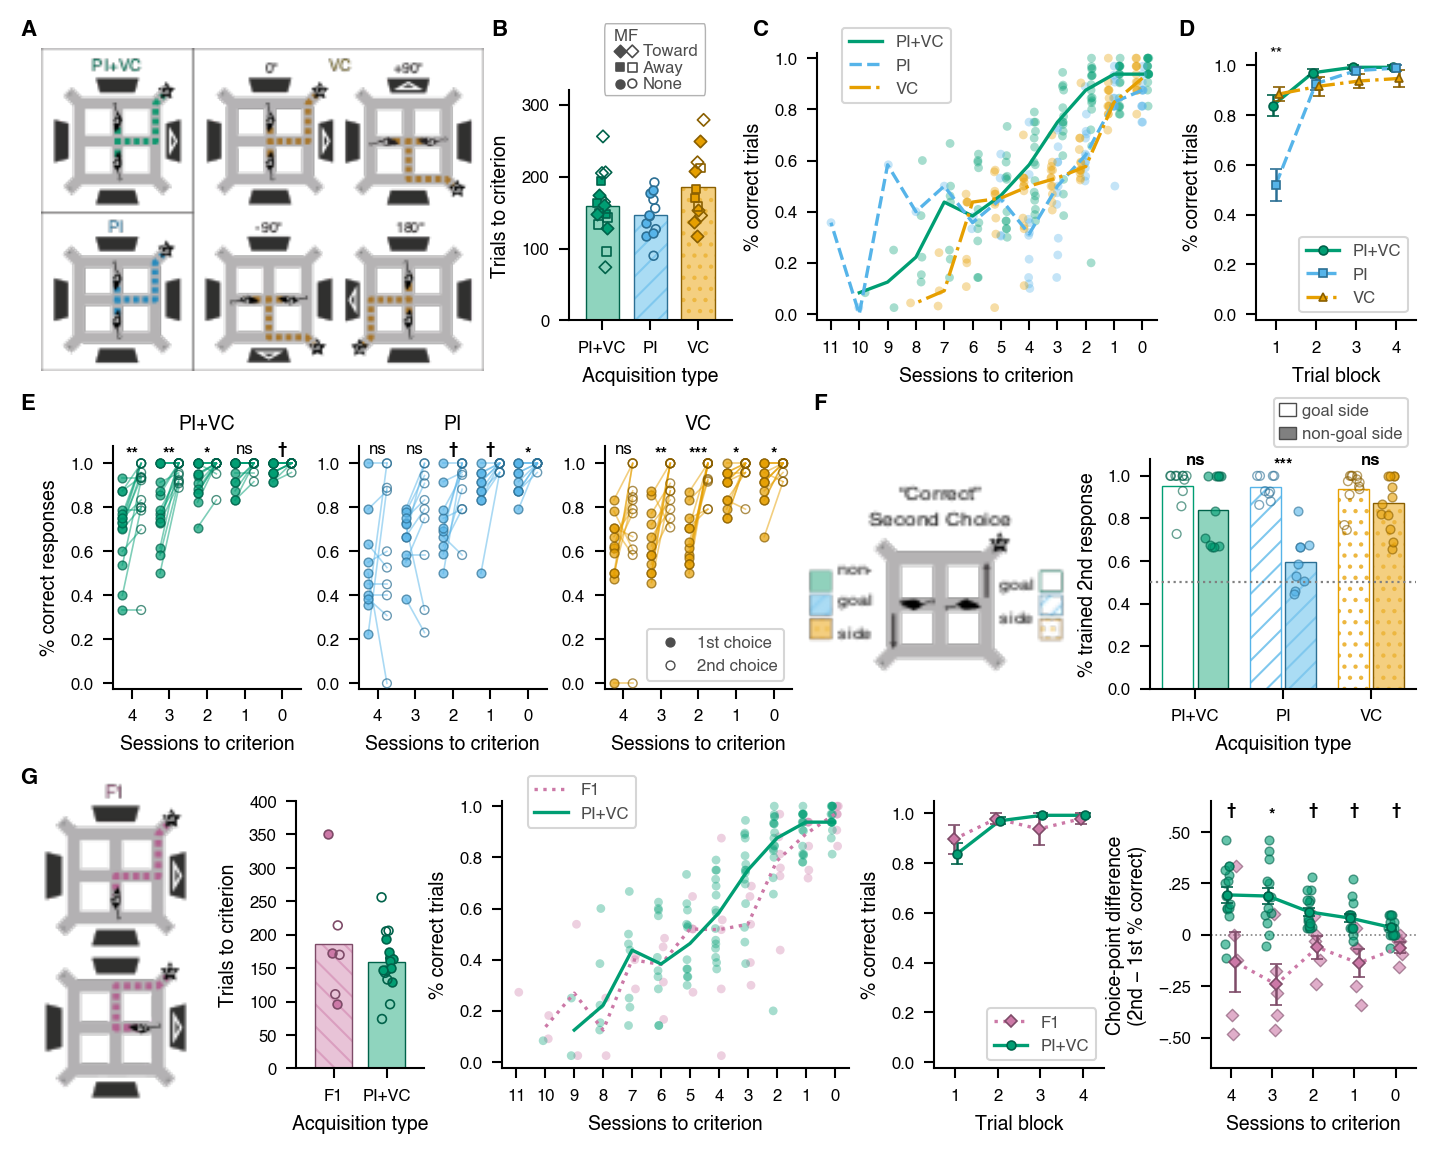

In [36]:
# ========== Compose Figure 2 ==========
import matplotlib.image as mpimg

# --- Page knobs ---
page_w = 180 / 25.4   # Wiley full-page canvas: 180 mm = 7.087 in (was 7.5 in = 190.5 mm)
row_h_in = 1.87           # height of one panel row (in) — unchanged from the 2-row layout
n_rows = 3                # row 1: A–D, row 2: E–F, row 3: G
page_h = row_h_in * n_rows   # 5.61 in (Wiley states no max height; Cell 225 mm = 8.86 in is a sanity cap)

# --- Row layout (one knob) ---
# Rows fill the page edge-to-edge (no inter-row gap). Row i (0 = top) spans
# [1 - (i+1)*row_height, 1 - i*row_height] in figure fractions.
row_height = 1.0 / n_rows
def row_bounds(i):
    top = 1.0 - i * row_height
    return top - row_height, top
row1_bottom, row1_top = row_bounds(0)
row2_bottom, row2_top = row_bounds(1)
row3_bottom, row3_top = row_bounds(2)

# --- Panel positions [left, bottom, width, height] in figure fractions ---
# Panel A slot expanded to 0.3322 of page_w (~2.35 in at page_w=7.087).
# B/C/D widths unchanged; B/C/D shifted right by 0.05 so D's right edge sits at 1.0.
# Row 3: G1 schematic, G2 trials-to-criterion, G3 learning curves, G4 blocks, G5 diff score.
positions = {
    'A': [0.0000, row1_bottom, 0.3322, row1_top - row1_bottom],
    'B': [0.3322, row1_bottom, 0.1850, row1_top - row1_bottom],
    'C': [0.5172, row1_bottom, 0.2997, row1_top - row1_bottom],
    'D': [0.8169, row1_bottom, 0.1831, row1_top - row1_bottom],
    'E':  [0.0000, row2_bottom, 0.5600, row2_top - row2_bottom],
    'F1': [0.5600, row2_bottom, 0.1825, row2_top - row2_bottom],
    'F2': [0.7425, row2_bottom, 0.2575, row2_top - row2_bottom],
    'G1': [0.0000, row3_bottom, 0.1450, row3_top - row3_bottom],
    'G2': [0.1450, row3_bottom, 0.1550, row3_top - row3_bottom],
    'G3': [0.3000, row3_bottom, 0.3000, row3_top - row3_bottom],
    'G4': [0.6000, row3_bottom, 0.1800, row3_top - row3_bottom],
    'G5': [0.7800, row3_bottom, 0.2200, row3_top - row3_bottom],
}

# --- Canvas visualization (debugging layout) ---
show_canvas_outline = False  # draws a faint border around the full figure
show_panel_outlines = False  # draws faint borders around each panel position

# --- Show/hide individual panels ---
show_a = True
show_b = True
show_c = True
show_d = True
show_e = True
show_f = True
show_g = True
show_panels = {'A': show_a, 'B': show_b, 'C': show_c, 'D': show_d, 'E': show_e,
               'F1': show_f, 'F2': show_f,
               'G1': show_g, 'G2': show_g, 'G3': show_g, 'G4': show_g, 'G5': show_g}

# --- Internal panel padding (axes inset within panel rect) ---
# Left/right are fractions of page_w. Top/bottom are fractions of PAD_REF_H (the
# 3.74 in two-row page these values were tuned at) and are rescaled to the current
# page_h inside axes_rect, so the padding in inches is unchanged when rows are added.
# Increase if axis labels, tick labels, or legends overflow the panel.
PAD_REF_H = 3.74
panel_pad = {
    'A': {'left': 0.02, 'right': 0.00, 'top': 0.03,   'bottom': 0.0125},
    'B': {'left': 0.06, 'right': 0.01, 'top': 0.10,   'bottom': 0.0925},
    'C': {'left': 0.05, 'right': 0.01, 'top': 0.05,   'bottom': 0.0925},
    'D': {'left': 0.06, 'right': 0.01, 'top': 0.05,   'bottom': 0.0925},
    'E': {'left': 0.04, 'right': 0.01, 'top': 0.075, 'bottom': 0.10},
    'F1': {'left': 0.00, 'right': 0.00, 'top': 0.045,  'bottom': 0.04},
    'F2': {'left': 0.06, 'right': 0.01, 'top': 0.0925, 'bottom': 0.10},
    'G1': {'left': 0.00, 'right': 0.00, 'top': 0.00,   'bottom': 0.00},   # tall 2-maze SVG: height-limited, use the whole row
    'G2': {'left': 0.055, 'right': 0.01, 'top': 0.05,  'bottom': 0.0925},   # top matches G3–G5 (no legend to clear)
    'G3': {'left': 0.045, 'right': 0.01, 'top': 0.05,  'bottom': 0.0925},
    'G4': {'left': 0.05, 'right': 0.01, 'top': 0.05,   'bottom': 0.0925},
    'G5': {'left': 0.065, 'right': 0.01, 'top': 0.05,  'bottom': 0.0925},
}
_v = PAD_REF_H / page_h   # vertical pad rescale (1.0 on the original 2-row page)

# --- Schematic scale: fraction of the padded slot the SVG may fill (1.0 = fill it).
# Applied inside axes_rect, centered in the slot, so the inline raster, the vector
# PDF overlay, and the SVG splice all shrink together.
schematic_scale = {'A': 1.0, 'F1': 1.0, 'G1': 0.9}    # G1 (2 stacked mazes): 90% of the full row height

def axes_rect(panel_name):
    """Convert panel rect to axes rect using panel_pad (+ schematic_scale, centered)."""
    pl, pb, pw, ph = positions[panel_name]
    pad = panel_pad[panel_name]
    l = pl + pad['left']
    b = pb + pad['bottom'] * _v
    w = pw - pad['left'] - pad['right']
    h = ph - (pad['top'] + pad['bottom']) * _v
    s = schematic_scale.get(panel_name, 1.0)
    if s != 1.0:
        l += w * (1 - s) / 2
        b += h * (1 - s) / 2
        w *= s
        h *= s
    return [l, b, w, h]

# --- Panel label knobs ---
# Slot-relative placement: each label sits at its panel slot's top-left corner,
# offset inward by label_x_offset (right) and label_y_offset (down).
# va='top', ha='left' anchors the label's top-left corner at (lx, ly).
# Cross-row alignment: all labels in a row share y.
label_fontsize = 8        # 8 pt bold, uppercase A/B/C (Cell floor; Wiley sets no size)
label_x_offset = 0.005    # fig-fraction inward from panel slot's left edge (~1 mm)
label_y_offset = 0.005    # fraction of PAD_REF_H inward from the slot's top edge (~0.5 mm); rescaled like the pads

# --- Schematic panels (SVG images) ---
panel_a_path = PROJECT_ROOT / 'figures' / 'images' / 'fig_2a.svg'
panel_f_image_path = PROJECT_ROOT / 'figures' / 'images' / 'fig_2f.svg'
panel_g_image_path = PROJECT_ROOT / 'figures' / 'images' / 'fig_2g.svg'
panel_a_dpi = 600                 # rasterization DPI for SVG inline preview (final PDF uses vector overlay regardless)
panel_a_interpolation = 'bilinear' # imshow interpolation: 'lanczos' (sharp), 'bilinear' (smoother), 'none'
# (panel-rect key, source SVG) for every schematic slot that is shown and whose file exists.
# Used below for the vector PDF overlay and by the SVG export cell.
schematic_panels = [(k, p) for k, p in (('A', panel_a_path), ('F1', panel_f_image_path),
                                        ('G1', panel_g_image_path))
                    if show_panels[k] and p.exists()]

fig = plt.figure(figsize=(page_w, page_h))

# Canvas outline for layout debugging
if show_canvas_outline:
    canvas_ax = fig.add_axes([0, 0, 1, 1])
    canvas_ax.set_xticks([]); canvas_ax.set_yticks([])
    for s in canvas_ax.spines.values():
        s.set_edgecolor('0.85'); s.set_linewidth(0.5)
    canvas_ax.set_facecolor('none')
    canvas_ax.set_zorder(-10)

if show_panel_outlines:
    for name, rect in positions.items():
        outline_ax = fig.add_axes(rect)
        outline_ax.set_xticks([]); outline_ax.set_yticks([])
        for s in outline_ax.spines.values():
            s.set_edgecolor('0.85'); s.set_linewidth(0.5)
        outline_ax.set_facecolor('none')
        outline_ax.set_zorder(-9)

def draw_schematic(name, path, letter):
    """Rasterize an SVG schematic into its panel slot (inline preview only; the saved
    PDF/SVG replace it with the true vector artwork below / in the export cell)."""
    ax = fig.add_axes(axes_rect(name))
    if path.exists():
        import cairosvg, io
        from PIL import Image
        png_data = cairosvg.svg2png(url=str(path), dpi=panel_a_dpi)
        img = np.array(Image.open(io.BytesIO(png_data)))
        im = ax.imshow(img, aspect='equal', interpolation=panel_a_interpolation)
        im.set_clip_on(False)
    else:
        ax.text(0.5, 0.5, f'{letter}\n(SVG missing)', ha='center', va='center',
                fontsize=8, color='gray', transform=ax.transAxes)
    ax.set_axis_off()
    return ax

# Panel A — image
if show_a:
    ax_a = draw_schematic('A', panel_a_path, 'A')

# ── panel_b tweakable parameters (defaults shown) ────────────────────────────
# Bar / scatter geometry
#   scatter_s         = STYLE_CFG['scatter_s']  (=10) scatter marker area (pt²)
#   bar_width         = 0.7        bar width in data units (x is categorical)
#   scatter_jitter    = 0.12       max ± horizontal jitter applied to scatter
# Axes
#   ylim              = (0, 320)   y-axis limits
#   yticks            = None       explicit y-tick locations (None → auto)
#   ylabel            = 'Trials to criterion'
#   xlabel            = 'Acquisition type'
#   xlim              = (-0.7, 2.7)
#   xticklabels       = None       (None → group names)
#   uniform_marker    = None       (None → approach shapes; G2 passes 'o' = circles for every rat)
# Line widths (defaults sourced from STYLE_CFG)
#   bar_edge_lw       = STYLE_CFG['bar_edge_lw']        bar outline
#   scatter_edge_lw   = STYLE_CFG['scatter_edge_lw_b']  scatter + legend marker stroke
#   legend_frame_lw   = STYLE_CFG['legend_frame_lw']    legend box outline
# Legend
#   show_legend       = True
#   legend_center_x   = 1.0        legend horizontal center (data x units)
#   legend_top_y      = 1.1        legend top edge (axes y fraction)
#   legend_box_w      = 1.45       legend box width  (data x units)
#   legend_box_h      = 0.3125     legend box height (axes y fraction)
#   legend_box_dx     = 0          horizontal nudge of the legend box only
#   legend_box_dy     = 0          vertical nudge of the legend box only (axes y units)
#   legend_content_dx = -0.25      horizontal nudge of M/F columns + markers
#   legend_fontsize   = 6
#   legend_marker_s   = STYLE_CFG['scatter_s']  (=10) in-legend marker area (pt²)
# Data source
#   data, groups      = None       (None → tta / GROUP_ORDER; Panel G2 passes tta_g / GROUP_ORDER_G)
# ─────────────────────────────────────────────────────────────────────────────
# Panel B
if show_b:
    ax_b = fig.add_axes(axes_rect('B'))
    panel_b(ax_b, show_legend=True, legend_top_y=1.3, legend_box_w=2.1,
                  legend_center_x=0.9, legend_box_dx=0.2, legend_box_dy=-0.01)

# ── panel_c tweakable parameters (defaults shown) ────────────────────────────
# Line / scatter geometry
#   line_lw                = 1.2          per-group median-line width (pt)
#   scatter_s              = STYLE_CFG['scatter_s']  (=10) per-rat scatter area (pt²)
#   scatter_alpha          = 0.35         scatter transparency
#   group_offset           = 0.20         horizontal spacing between groups at one session_rank
#   within_jitter          = 0.03         max ± horizontal jitter inside a group
# Axes
#   xlim                   = None         (None → (x_max+0.5, -0.5))
#   xticks                 = None         (None → range(0, x_max+1))
#   xlabel                 = 'Sessions to criterion'
#   ylim                   = (-0.025, 1.02)
#   yticks                 = None         (None → [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
#   ylabel                 = '% correct trials'
# Legend
#   show_legend            = True
#   legend_loc             = 'upper left'
#   legend_fontsize        = None         (None → rcParams default = 6)
#   legend_handletextpad   = 0.8
#   legend_borderpad       = 0.4
#   legend_bbox_to_anchor  = None         (set to e.g. (1.0, 1.0) to free-place the legend)
#   legend_top_y           = None         shorthand: anchor legend top edge at axes-y;
#                                         picks anchor-x from legend_loc (left/right/center).
#                                         Ignored if legend_bbox_to_anchor is set.
#   legend_x               = None         anchor x in axes fractions (e.g. 1.05 = just right of axes).
#                                         Pins the side named by legend_loc; combine with legend_top_y for full xy.
#                                         Ignored if legend_bbox_to_anchor is set.
# Data source
#   data, groups, labels   = None         (None → sess_acc / GROUP_ORDER / group names)
#   min_n                  = None         hide the median line where < min_n rats remain (G3 uses 2)
# Placement (panel_pad['C'] above — fractions of page_w / PAD_REF_H)
#   left=0.05, right=0.01, top=0.08, bottom=0.05
#     ↑ raise top, lower bottom to slide plot up; mirror to slide down.
#     bottom matches panel_pad['B']['bottom'] so the B/C x-axes align.
# ─────────────────────────────────────────────────────────────────────────────
# Panel C
if show_c:
    ax_c = fig.add_axes(axes_rect('C'))
    panel_c(ax_c, show_legend=True,  legend_x=0.05, legend_top_y=1.125)

# ── panel_d tweakable parameters (defaults shown) ────────────────────────────
# Line / marker / errorbar geometry
#   line_lw                = 1.2          per-group connecting-line width (pt)
#   marker_size            = STYLE_CFG['marker_size']  (=3.16) errorbar marker diameter (pt)
#   marker_edge_lw         = STYLE_CFG['marker_edge_lw_d']
#   cap_size               = STYLE_CFG['cap_size']
#   err_lw                 = STYLE_CFG['err_lw']
#   group_offset           = 0.08         horizontal offset between groups at one block
#   error_kind             = 'sem'        'iqr' → median + IQR; anything else → mean ± SEM
# Axes
#   xlim                   = (0.5, 4.5)
#   xticks                 = None         (None → [1, 2, 3, 4])
#   xlabel                 = 'Trial block'
#   ylim                   = (-0.025, 1.05)
#   yticks                 = None         (None → [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
#   ylabel                 = '% correct trials'
# Annotation (significance star above block)
#   star_text              = '***'        ('' → no star; Panel G4 passes '')
#   star_x                 = 1            x-data position of star
#   star_y                 = 1.02         y-data position of star
#   star_fontsize          = STYLE_CFG['star_fontsize']
# Legend
#   show_legend            = True
#   legend_loc             = 'lower right'
#   legend_fontsize        = None         (None → rcParams default = 6)
#   legend_handletextpad   = 0.8
#   legend_borderpad       = 0.4
#   legend_bbox_to_anchor  = None         (set to e.g. (1.0, 1.0) to free-place the legend)
#   legend_top_y           = None         shorthand: anchor legend top edge at axes-y;
#                                         picks anchor-x from legend_loc (left/right/center).
#                                         Ignored if legend_bbox_to_anchor is set.
# Data source
#   data, groups, labels   = None         (None → block_acc / GROUP_ORDER / group names)
# Placement (panel_pad['D'] above — fractions of page_w / PAD_REF_H)
#   left=0.06, right=0.01, top=0.03, bottom=0.10
#     ↑ raise top, lower bottom to slide plot up; mirror to slide down.
#     Match panel_pad['B']['bottom']=0.05 to align D's x-axis with B's (also nudge top up by 0.05).
# ─────────────────────────────────────────────────────────────────────────────
# Panel D
if show_d:
    ax_d = fig.add_axes(axes_rect('D'))
    panel_d(ax_d, star_text=D_BLOCK1_STAR, show_legend=True)

# ── panel_e tweakable parameters (defaults shown) ────────────────────────────
# Scatter / pair-line geometry
#   scatter_s              = STYLE_CFG['scatter_s']  (=10) per-rat scatter area (pt²)
#   scatter_alpha          = 0.7
#   marker_edge_lw         = STYLE_CFG['marker_edge_lw_e']
#   pair_line_lw           = STYLE_CFG['pair_line_lw']
#   pair_line_alpha        = 0.5         within-rat 1st↔2nd connector opacity
#   cp_spread              = 0.5         x-distance between paired choice points
# Axes
#   xlim                   = (4.5, -0.5)  reversed so '4' is left, '0' is right
#   xticks                 = None         (None → [4, 3, 2, 1, 0])
#   xticklabels            = None         (None → string of each xtick)
#   xlabel                 = 'Sessions to criterion'
#   ylim                   = (-0.025, 1.08)
#   yticks                 = None         (None → [0.25, 0.5, 0.75, 1.0])
#   ylabel                 = '% correct responses'  (only the leftmost subplot uses it)
#   show_titles            = True         per-subplot title = group name
# Annotation (significance stars / ns / cross above each session)
#   star_y                 = 1.01
#   ns_y_nudge             = 0.02
#   cross_y_nudge          = 0.02
#   star_fontsize          = STYLE_CFG['star_fontsize']
#   ns_fontsize            = STYLE_CFG['ns_fontsize']
# Legend (drawn on the rightmost subplot only)
#   show_legend            = True
#   legend_loc             = 'lower right'
#   legend_fontsize        = None         (None → rcParams default = 6)
#   legend_handletextpad   = 0.6
#   legend_borderpad       = 0.4
#   legend_bbox_to_anchor  = None
#   legend_top_y           = None         shorthand: anchor legend top edge at axes-y
#   legend_x               = None         anchor x in axes fractions
# Subplot layout (set in the loop below — fractions of the E panel rect)
#   e_pad_left             = 0.06         left margin before the first subplot
#   e_pad_gap              = 0.08         gap between adjacent subplots (raise to widen gaps)
# Placement (panel_pad['E'] above — fractions of page_w / PAD_REF_H)
#   left=0.04, right=0.01, top=0.1025, bottom=0.10
# ─────────────────────────────────────────────────────────────────────────────
# Panel E — 3 subplots within the E region
if show_e:
    e_rect = axes_rect('E')
    e_n = len(GROUP_ORDER)
    e_pad_left = 0.06   # fraction of E width for left margin
    e_pad_gap = 0.08    # fraction of E width between subplots (bumped to keep tick labels off neighbors)
    e_plot_w = (1 - e_pad_left - e_pad_gap * (e_n - 1)) / e_n
    e_axes = []
    for i in range(e_n):
        left = e_rect[0] + e_rect[2] * (e_pad_left + i * (e_plot_w + e_pad_gap))
        e_ax = fig.add_axes([left, e_rect[1],
                             e_rect[2] * e_plot_w, e_rect[3]])
        e_axes.append(e_ax)
    panel_e(e_axes, show_legend=True)

# Panel F1 — image (left half of F slot)
if show_f:
    ax_f1 = draw_schematic('F1', panel_f_image_path, 'F')

# ── panel_f tweakable parameters (defaults shown) ────────────────────────────
# Bar / scatter geometry
#   bar_width              = 0.35         bar width in data units (x is categorical)
#   bar_gap                = 0.05         horizontal gap between goal/non-goal bars
#   scatter_s              = STYLE_CFG['scatter_s']  (=10) per-rat scatter area (pt²)
#   scatter_alpha          = 0.6
# Reference line
#   chance_line            = True         draw 0.5 dotted reference line
#   axhline_lw             = STYLE_CFG['axhline_lw']
# Line widths
#   bar_edge_lw            = STYLE_CFG['bar_edge_lw']        bar outline
#   scatter_edge_lw        = STYLE_CFG['scatter_edge_lw_f']  scatter stroke
#   legend_frame_lw        = STYLE_CFG['legend_frame_lw']    legend swatch outline
# Annotation (significance star/ns above each group)
#   star_y                 = 1.02         y-data position of '*' / '**' / '***'
#   ns_y                   = 1.04         y-data position of 'ns' label
#   star_fontsize          = STYLE_CFG['star_fontsize']
# Axes
#   xticks                 = None         (None → np.arange(len(GROUP_ORDER)))
#   xticklabels            = None         (None → GROUP_ORDER)
#   xlabel                 = None         no xlabel by default
#   ylim                   = (0.0, 1.08)
#   yticks                 = None         (None → matplotlib default)
#   ylabel                 = '% trained 2nd response'
# Legend
#   show_legend            = True
#   legend_loc             = 'upper right'
#   legend_bbox            = (1, 1.25)    bbox_to_anchor; legend_top_y overrides y component
#   legend_top_y           = None         shorthand: pin legend top-edge at axes-y; overrides legend_bbox[1]
#   legend_fontsize        = 6
#   legend_markerscale     = 0.3
#   legend_handlelength    = 1.0
#   legend_handleheight    = 0.8
#   legend_handletextpad   = 0.4
#   legend_borderpad       = 0.3
# Placement (panel_pad['F2'] above — fractions of page_w / PAD_REF_H)
#   left=0.04, right=0.01, top=0.0925, bottom=0.10
# ─────────────────────────────────────────────────────────────────────────────
# Panel F2 — plot (right half of F slot)
if show_f:
    ax_f2 = fig.add_axes(axes_rect('F2'))
    panel_f(ax_f2, show_legend=True, legend_top_y=1.3, xlabel='Acquisition type', ylabel='% trained 2nd response')

# ── Panel G (row 3) ──────────────────────────────────────────────────────────
# G1 schematic (figures/images/fig_2g.svg). G2/G3/G4 reuse panel_b/panel_c/panel_d with the
# Panel G data (tta_g / sess_acc_g / block_acc_g) and GROUP_ORDER_G — every knob listed
# above for B/C/D applies here too. G5 = panel_g_diff (knobs in its definition cell):
#   jitter=0.08, group_offset=0.10, ylim=(-0.65, 0.65), star_y=0.55, show_stars=True,
#   show_legend (off here), legend_loc='upper left', legend_x / legend_top_y as panel_c.
# G2 uses ylim=(0, 400) (B uses 320): fixed-1st rat 123 needed 350 trials.
# G2 legend geometry is in data-x units: the axis spans 2.4 units (two bars) vs 3.4 in B,
# so legend_center_x / legend_box_w are set for the narrower axis.
# Placement: panel_pad['G1'..'G5'] above (G2..G4 mirror B..D; G5 has a 2-line y-label).
# ─────────────────────────────────────────────────────────────────────────────
if show_g:
    ax_g1 = draw_schematic('G1', panel_g_image_path, 'G')
    ax_g2 = fig.add_axes(axes_rect('G2'))
    panel_b(ax_g2, data=tta_g, groups=GROUP_ORDER_G,
            xticklabels=[GROUP_LABELS_G[g] for g in GROUP_ORDER_G],
            xlim=(-0.7, 1.7), ylim=(0, 400), uniform_marker='o',   # approach not meaningful for F1
            show_legend=False)   # M/F key already shown in Panel B
    ax_g3 = fig.add_axes(axes_rect('G3'))
    panel_c(ax_g3, data=sess_acc_g, groups=GROUP_ORDER_G, labels=GROUP_LABELS_G, min_n=2,
            show_legend=True, legend_x=0.05, legend_top_y=1.125)
    ax_g4 = fig.add_axes(axes_rect('G4'))
    panel_d(ax_g4, data=block_acc_g, groups=GROUP_ORDER_G, labels=GROUP_LABELS_G,
            star_text='', show_legend=True)
    ax_g5 = fig.add_axes(axes_rect('G5'))
    # G5 legend off: G4 (same row) carries the identical marker + line key, and every
    # open corner of G5 holds data. Flip show_legend=True (+ legend_loc/legend_x/legend_top_y) to restore.
    panel_g_diff(ax_g5, show_legend=False)

# Panel labels — panel_labels maps a position key → display letter; missing key = no label
panel_labels = {'A': 'A', 'B': 'B', 'C': 'C', 'D': 'D', 'E': 'E', 'F1': 'F', 'G1': 'G'}
for name, rect in positions.items():
    if not show_panels.get(name, True):
        continue
    label_text = panel_labels.get(name)
    if label_text is None:
        continue
    lx = rect[0] + label_x_offset
    ly = rect[1] + rect[3] - label_y_offset * _v
    fig.text(lx, ly, label_text, fontsize=label_fontsize, fontweight='bold',
             va='top', ha='left')

plt.show()


In [37]:
# Export the composed figure as a fully-vector SVG.
#
# We build the SVG directly instead of converting the finished PDF with
# `pdftocairo -svg`: the PDF's schematic panels are pikepdf `add_overlay` Form
# XObjects (nested transform + BBox clip), and pdftocairo's SVG backend can
# mis-apply that nesting and scramble the clipped/dashed artwork (this broke
# figure3's Panel A). Instead we save matplotlib's own SVG (vector plot panels +
# labels; schematic panels rasterized) and splice each pristine source SVG in
# over its panel as a nested <svg>, so the schematics stay pixel-perfect vector.
#
# Each Illustrator export carries a global <style> (.st0..) and element ids
# (clippath..). SVG CSS/ids are document-global, so inlining more than one would
# collide (this scrambled figure2's two schematics). `_isolate` prefixes every
# class token and id (and their url(#..)/href references) per panel first.
#
# Hatching: matplotlib writes bar hatches as SVG <pattern> fills, and Adobe
# Illustrator (30.2) silently drops those on import - figure2's
# composed SVG lost every hatched bar the first time it was opened and re-saved
# in AI (the PDF's native pattern fills were fine). `_expand_hatches` therefore
# rewrites each `fill: url(#h..)` as the same drawing done explicitly - face
# fill, copies of the tile's hatch strokes (each clipped to its 72x72 tile, all
# clipped to the shape), then the shape's edge on top - i.e. what AI's own
# Object > Expand produces; plain paths + clipPaths survive every renderer.
# Same cell in figure2/3/4; figure5 reuses
# the helpers.
import math
import re
import xml.etree.ElementTree as ET

_NS = 'http://www.w3.org/2000/svg'
_IMG = f'{{{_NS}}}image'
ET.register_namespace('', _NS)
ET.register_namespace('xlink', 'http://www.w3.org/1999/xlink')

# (panel-rect key, source SVG) for every rasterized schematic panel (A, F1, G1),
# as built by the compose cell.
_schematics = list(schematic_panels)

def _isolate(root, prefix):
    """Prefix this SVG's class tokens and ids (+ their references) so its global
    styles/ids cannot collide with another inlined SVG's."""
    ids, classes = set(), set()
    for el in root.iter():
        if el.get('id'):
            ids.add(el.get('id'))
        if el.get('class'):
            classes.update(el.get('class').split())
    for st in root.iter(f'{{{_NS}}}style'):
        classes.update(re.findall(r'\.([A-Za-z_][\w-]*)', st.text or ''))

    def _fix(v):
        return re.sub(r'url\(#([^)]+)\)',
                      lambda m: f'url(#{prefix}{m.group(1)})' if m.group(1) in ids
                      else m.group(0), v)
    for el in root.iter():
        if el.get('id') in ids:
            el.set('id', prefix + el.get('id'))
        if el.get('class'):
            el.set('class', ' '.join(prefix + t for t in el.get('class').split()))
        for k, v in list(el.attrib.items()):
            if 'url(#' in v:
                el.set(k, _fix(v))
            if (k == 'href' or k.endswith('}href')) and v.startswith('#') and v[1:] in ids:
                el.set(k, '#' + prefix + v[1:])
    for st in root.iter(f'{{{_NS}}}style'):
        css = st.text or ''
        for t in sorted(classes, key=len, reverse=True):
            css = re.sub(r'\.' + re.escape(t) + r'\b', f'.{prefix}{t}', css)
        st.text = _fix(css)
    return root


def _translate_d(d, dx, dy):
    """Shift an absolute-command path (M/L/Q/C/Z, as matplotlib writes) by (dx, dy)."""
    out, i = [], 0
    for t in re.findall(r'[A-Za-z]|-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?', d):
        if t.isalpha():
            if t not in 'MLQCZz':
                raise ValueError(f'unsupported path command {t!r}')
            out.append(t)
            i = 0
        else:
            out.append(f'{float(t) + (dx if i % 2 == 0 else dy):g}')
            i += 1
    return ' '.join(out)


def _expand_hatches(root):
    """Replace every `fill: url(#..)` that points at a matplotlib hatch <pattern>
    (a userSpaceOnUse tile in the document's own <defs>) with the same drawing done
    explicitly: the face fill (if the tile has one), then copies of the tile's
    hatch strokes - each clipped to its tile, all clipped to the shape - then the
    shape's own edge stroke on top. The now-unused <pattern> defs are removed.
    Returns the number of shapes expanded."""
    defs = root.findall(f'{{{_NS}}}defs')
    patterns = {p.get('id'): (d, p) for d in defs for p in d.findall(f'{{{_NS}}}pattern')
                if p.get('patternUnits') == 'userSpaceOnUse' and p.get('width') and p.get('height')}
    if not patterns:
        return 0
    parent = {c: p for p in root.iter() for c in p}
    num = r'-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?'
    n_shape = n_tile = 0
    for el in list(root.iter()):
        st = el.get('style') or ''
        m = re.search(r'fill:\s*url\(#([^)]+)\)', st)
        if not m or m.group(1) not in patterns or el.tag != f'{{{_NS}}}path' or not el.get('d'):
            continue
        pat = patterns[m.group(1)][1]
        tw, th = float(pat.get('width')), float(pat.get('height'))
        px, py = float(pat.get('x', 0)), float(pat.get('y', 0))
        shape_d = el.get('d')
        nums = [float(v) for v in re.findall(num, shape_d)]
        x0, x1, y0, y1 = min(nums[0::2]), max(nums[0::2]), min(nums[1::2]), max(nums[1::2])
        # matplotlib's tile = a background rect (the face colour; 'none' for a
        # hatch-only overlay) + the hatch strokes. A shape drawn with an edge keeps
        # its stroke-* properties next to the pattern fill in the same style string.
        rect = pat.find(f'{{{_NS}}}rect')
        face = rect.get('fill', 'none') if rect is not None else 'none'
        content = list(pat.iter(f'{{{_NS}}}path'))
        props = [p.strip() for p in st.split(';') if p.strip() and not p.strip().startswith('fill:')]
        stroke = [p for p in props if p.startswith('stroke')]
        other = [p for p in props if not p.startswith('stroke')]      # opacity, fill-opacity
        n_shape += 1
        cid = f'hatchshape{n_shape}'
        cp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': cid})
        ET.SubElement(cp, f'{{{_NS}}}path', {'d': shape_d})
        outer = ET.Element(f'{{{_NS}}}g')
        for k, v in el.attrib.items():          # keep the shape's clip-path / id / transform
            if k not in ('d', 'style'):
                outer.set(k, v)
        if other:
            outer.set('style', '; '.join(other))
        if face != 'none':                                             # 1) face fill
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': f'fill: {face}; stroke: none'})
        shape_g = ET.SubElement(outer, f'{{{_NS}}}g', {'clip-path': f'url(#{cid})'})   # 2) hatch
        for i in range(math.floor((x0 - px) / tw), math.ceil((x1 - px) / tw)):
            for j in range(math.floor((y0 - py) / th), math.ceil((y1 - py) / th)):
                dx, dy = px + i * tw, py + j * th
                n_tile += 1
                tid = f'hatchtile{n_tile}'
                tcp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': tid})
                ET.SubElement(tcp, f'{{{_NS}}}rect', {'x': f'{dx:g}', 'y': f'{dy:g}',
                                                      'width': f'{tw:g}', 'height': f'{th:g}'})
                tg = ET.SubElement(shape_g, f'{{{_NS}}}g', {'clip-path': f'url(#{tid})'})
                for c in content:
                    try:
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': _translate_d(c.get('d'), dx, dy), 'style': c.get('style', '')})
                    except ValueError:      # relative/arc commands: shift by transform instead
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': c.get('d'), 'style': c.get('style', ''),
                                       'transform': f'translate({dx:g} {dy:g})'})
        if any(re.match(r'stroke:\s*(?!none)', p) for p in stroke):       # 3) edge on top
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': 'fill: none; ' + '; '.join(stroke)})
        p = parent[el]
        p.insert(list(p).index(el), outer)
        p.remove(el)
    for d, pat in patterns.values():
        d.remove(pat)
    for d in defs:                              # matplotlib's trailing hatch-only <defs>
        if len(d) == 0 and d in parent:
            parent[d].remove(d)
    return n_shape


_svg = FIG_OUT / 'figure2.svg'
fig.savefig(_svg)  # vector plot panels + labels; schematic panels are raster <image>

_tree = ET.parse(_svg)
_root = _tree.getroot()
_n_hatch = _expand_hatches(_root)
_n_spliced = 0

if _schematics:
    _fig_g = _root.find(f'{{{_NS}}}g')  # matplotlib wraps everything in <g id="figure_1">

    # In these figures the only <image> elements are the schematic panels we are
    # about to replace; assert the count so an unexpected raster can't be
    # silently dropped (leave the schematics rasterized if it is off).
    _img_parents = [(p, ch) for p in _root.iter() for ch in list(p) if ch.tag == _IMG]
    if len(_img_parents) == len(_schematics):
        # Insert the vector schematics where the first raster panel sat, so the
        # bold panel labels (added last -> drawn on top) stay visible.
        _insert_at = min(i for i, ch in enumerate(list(_fig_g))
                         if any(e.tag == _IMG for e in ch.iter()))
        for _p, _img in _img_parents:
            _p.remove(_img)
        # SVG user units = inches*72 with y pointing down, so flip the
        # bottom-origin fraction to a top y. 'meet' == imshow aspect='equal'.
        _doc_w, _doc_h = page_w * 72.0, page_h * 72.0
        for _k, (_name, _path) in enumerate(_schematics):
            _ax_l, _ax_b, _ax_w, _ax_h = axes_rect(_name)
            _a_root = _isolate(ET.parse(_path).getroot(), f'p{_k}_')
            # Strip the schematic's <metadata> and any Adobe-namespace elements
            # (Illustrator's private <aipgf> editing payload). Nested inside a
            # foreign document that blob makes Illustrator try - and fail - to
            # restore the original file instead of reading the SVG, so the
            # composed export would not open in AI. Metadata only; rendering
            # is unaffected (the pristine source SVG keeps its payload).
            _AI = '{http://ns.adobe.com/AdobeIllustrator/10.0/}'
            for _parent in list(_a_root.iter()):
                for _ch in [c for c in list(_parent)
                            if c.tag == f'{{{_NS}}}metadata' or str(c.tag).startswith(_AI)]:
                    _parent.remove(_ch)
            _nested = ET.Element(f'{{{_NS}}}svg')
            _nested.set('x', f'{_ax_l * _doc_w:.4f}')
            _nested.set('y', f'{(1.0 - _ax_b - _ax_h) * _doc_h:.4f}')
            _nested.set('width', f'{_ax_w * _doc_w:.4f}')
            _nested.set('height', f'{_ax_h * _doc_h:.4f}')
            _nested.set('viewBox', _a_root.get('viewBox'))
            _nested.set('preserveAspectRatio', 'xMidYMid meet')
            for _child in list(_a_root):
                _nested.append(_child)
            _fig_g.insert(_insert_at, _nested)
        _n_spliced = len(_schematics)
    else:
        print(f'WARNING: found {len(_img_parents)} <image> element(s), expected '
              f'{len(_schematics)}; schematics left rasterized: {_svg}')

_tree.write(_svg, xml_declaration=True, encoding='utf-8')
print(f'Saved SVG: {_svg} ({_n_spliced} schematic panel(s) spliced in as vector; '
      f'{_n_hatch} hatched shape(s) expanded to plain strokes)')

Saved SVG: figures/images/figure2.svg (3 schematic panel(s) spliced in as vector; 7 hatched shape(s) expanded to plain strokes)
